# Modèle d’Ising en dimension finie

In [2]:
# bibliothèques utilisées 
import random
from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt
from typing import Iterable

verbosity = 1 # niveau de verbosité
# 0 : verbosité minimale 
# 1 : variables et résultats importants
# 2 : ensemble des variables et des résultats

# Exercise 1 Le modèle d’Ising en une dimension

L’hamiltonien du système est donné par :
$$ \mathcal{H} = - J \sum_{i = 0}^N s_i s_{i+1} $$
où $J$ est la constante de couplage entre spins voisins (nous considérerons $J > 0$, cas ferromagnétique).


# Part I — Développement haute température

# Q1

## a. 
La fonction de partition $Z_N (\beta)$ s'ecrit telle que :
$$ Z_N (\beta) = \sum_{\{s\}} e^{-\beta \mathcal{H}}  = \sum_{\{s\}} e^{-\beta \left( - J \sum_{i = 0}^N s_i s_{i+1} \right)}  = \sum_{\{s\}} e^{\beta J \sum_{i = 0}^N s_i s_{i+1}}  = \sum_{\{s\}} \prod_{i = 0}^N e^{\beta J s_i s_{i+1}} $$ 
où l'on note la somme des configurations des $N$ sites étudiés:
$$\sum_{\{s\}} = \sum_{k = 1}^N \sum_{s_k \in \{-1, 1\}} = \sum_{s_1 \in \{-1, 1\}} \sum_{s_2 \in \{-1, 1\}} \cdots \sum_{s_{N-1} \in \{-1, 1\}} \sum_{s_{N} \in \{-1, 1\}}$$

## b. 
En utilisant l'identité : $e^{\beta x} = \cosh(\beta)\left(1 + x \tanh(\beta)\right)$ où $x=\pm 1$

On obtient : 
$$ Z_N (\beta) = \sum_{\{s\}} \prod_{i = 0}^N e^{\beta J s_i s_{i+1}} = \sum_{\{s\}} \prod_{i = 0}^N \cosh(\beta J) \left(1 + s_i s_{i + 1} \tanh(\beta J)\right) = \sum_{\{s\}} \cosh^{N+1}(\beta J)  \prod_{i = 0}^N \left(1 + s_i s_{i + 1} \kappa\right) = \cosh^{N+1}(\beta J)\sum_{\{s\}} \prod_{i = 0}^N \left(1 + s_i s_{i + 1} \kappa\right)$$
Où l'on a utilisé que $\kappa = \tanh(\beta J)$ et on note ici que l'on a bien $N + 1$ liaisons entre les sites ($N-1$ liaisons entre les $N$ sites étudiés et $2$ liaisons aux bords($s_0 - s_1$ et $s_{N}-s_{N+1}$)).

## Q2

## a. 
On réalise un développement en régime de haute température ($T \to \infty$), ce qui revient à considérer $\beta \to 0$. Dans cette limite, $\kappa = \tanh(\beta J) \approx 0$. On effectue alors un développement en série de la fonction de partition $Z_N(\beta)$ autour de $\kappa$.
La fonction de partition s'écrit initialement :
$$Z_N(\beta) = \cosh^{N+1}(\beta J) \sum_{\{s\}} \prod_{i=0}^N \left(1 + s_i s_{i+1} \kappa \right)$$
En développant le produit, cela devient :
$$Z_N(\beta) = \cosh^{N+1}(\beta J) \sum_{\{s\}} \left( 
1 + \kappa \sum_{0 \le i \le N} s_i s_{i+1} 
+ \kappa^2 \sum_{0 \le i < j \le N} s_i s_{i+1} s_j s_{j+1} 
+ \kappa^3 \sum_{0 \le i < j < k \le N} s_i s_{i+1} s_j s_{j+1} s_k s_{k+1} 
+ \cdots 
\right)$$
où chaque terme correspond à un ordre croissant en $\kappa$. 

![illustration](./assets/illu_2.png)

Chaque terme du développement en série de la fonction de partition $Z_N(\beta)$ peut être représenté par un diagramme, car les interactions entre les spins $s_i$ et $s_{i+1}$ sont locales et associées à un facteur $\kappa = \tanh(\beta J)$. Chaque lien dans le diagramme correspond à un terme $s_i s_{i+1} \kappa$, reliant deux sites voisins. L’ordre du développement en $\kappa$ détermine le nombre de liens dans le diagramme : un terme d’ordre $\mathcal{O} (1)$ correspond à un réseau sans liens, un terme d’ordre 1 ($\kappa$) représente une configuration avec un seul lien, et un terme d’ordre n ($\kappa^n$) décrit un réseau comportant $n$ liens distincts. Les diagrammes sont ainsi une représentation visuelle efficace pour illustrer les interactions locales, organiser les calculs et relier directement les contributions à l’ordre du développement.

![illustration](./assets/illu_3.png)

Ici on prend l'exemple d'un diagramme d'ordre 1 ($\kappa$) où l'on observe un unique lien en noté en rouge.

### b. 
Pour $N = 3$, on obtient $N+2=5$ sites et $N+1=4$ liaisons. 

![illustration](./assets/illu_1.png)

Dans cette illustration, les conditions aux bords sont représentées en vert ($s_0 = s_4 = 1$). 

De plus, toutes les liaisons possible sont schématisé dans le graphe ci-dessous :

![illustration](./assets/illu_13.png)


On peut alors écrire explicitement la fonction de partition $Z_N (\beta)$ sous la forme suivante :
$$Z_N (\beta) = \cosh^{N+1}(\beta J)\sum_{\{s\}} \prod_{i = 0}^N \left(1 + s_i s_{i + 1} \kappa\right) = \cosh^{4}(\beta J)\sum_{\{s\}}\left(1 + s_0 s_{1} \kappa\right)\left(1 + s_1 s_{2} \kappa\right)\left(1 + s_2 s_{3} \kappa\right) \left(1 + s_3 s_{4} \kappa\right) $$
$$ = \cosh^{4}(\beta J)\sum_{\{s\}} \left[ 1 + \kappa \sum_{0 \le i \le 3} s_i s_{i+1} + \kappa^2 \sum_{0 \le i < j \le 3} s_i s_{i+1}s_j s_{j+1} + \kappa^3 \sum_{0 \le i < j < k \le 3} s_i s_{i+1}s_j s_{j+1}s_k s_{k+1} + \kappa^4 \sum_{0 \le i < j < k < m \le 3} s_i s_{i+1}s_j s_{j+1}s_k s_{k+1} s_m s_{m+1} \right]$$

On peut réécrire la somme des configurations de spins $\{s = \pm 1\}$ telle que : 
$$\sum_{\{s\}} = \sum_{k = 1}^N \sum_{s_k = \pm 1} = \sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1}$$
De plus, on utilise les deux résultats suivants :
$$\sum_{s_k = \pm 1} s_k^n = 1^n + (-1)^n = 1 + (-1)^n \begin{cases} = 0 \text{ si }n\text{ est impaire} \\ = 2 \text{ si }n\text{ est paire} \end{cases} $$
On peut alors écrire l'ensemble des sommes tel que :
$$\sum_{\{s\}} = \sum_{k = 1}^N \sum_{s_k = \pm 1} s_k^n = \begin{cases} = 0 \text{ si }n\text{ est impaire} \\ = 2^N \text{ si }n\text{ est paire} \end{cases}  $$

On décompose les trois sommes :

Le premier terme représente l'unique configuration où il y a aucune liaison :
$$\sum_{k = 1}^3 \sum_{s_k = \pm 1} 1 = \sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1} 1 = 2 \cdot 2 \cdot 2 = 8 $$
Le second terme représente l'ensemble des configurations présentant une unique liaison :
$$\sum_{k = 1}^3 \sum_{s_k = \pm 1} \left( \sum_{0 \le i \le 3} s_i s_{i+1} \right) = \sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1} \left(s_0 s_1 + s_1 s_2 + s_2 s_3 + s_3 s_4 \right) = s_0\sum_{s_1 = \pm 1} s_1 \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1} + \sum_{s_1 = \pm 1} s_1 \sum_{s_2 = \pm 1} s_2 \sum_{s_3 = \pm 1} + \sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} s_2 \sum_{s_3 = \pm 1} s_3 + s_4\sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1} s_3 = 0 $$
Le troisième terme représente l'ensemble des configurations à deux liaisons :
$$\sum_{k = 1}^3 \sum_{s_k = \pm 1} \left( \sum_{0 \le i < j \le 3} s_i s_{i+1} s_j s_{j+1} \right) $$
$$\begin{aligned}
& = \sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1} \left(s_0s_1s_1s_2 + s_0s_1s_2s_3 + s_0s_1s_3s_4 + s_1s_2s_2s_3 + s_1s_2s_3s_4 + s_2s_3s_3s_4 \right) \\
& = s_0\sum_{s_1 = \pm 1} s_1^2 \sum_{s_2 = \pm 1} s_2 \sum_{s_3 = \pm 1} + s_0\sum_{s_1 = \pm 1} s_1 \sum_{s_2 = \pm 1} s_2 \sum_{s_3 = \pm 1} s_3 + s_0s_4\sum_{s_1 = \pm 1} s_1 \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1} s_3 +  \sum_{s_1 = \pm 1} s_1 \sum_{s_2 = \pm 1} s_2^2 \sum_{s_3 = \pm 1} s_3 + s_4\sum_{s_1 = \pm 1} s_1 \sum_{s_2 = \pm 1} s_2 \sum_{s_3 = \pm 1} s_3 + s_4 \sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} s_2 \sum_{s_3 = \pm 1} s_3^2 \\
&= 0 \\ 
\end{aligned}$$
Le quatrième terme représente l'ensemble des configurations à trois liaisons :
$$\sum_{k = 1}^3 \sum_{s_k = \pm 1} \left(\sum_{0 \le i < j < k \le 3} s_i s_{i+1} s_j s_{j+1} s_k s_{k+1} \right)$$
$$\begin{aligned}
& = \sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1} \left(s_0s_1s_1s_2s_2s_3+s_0s_1s_1s_2s_3s_4+s_0s_1s_2s_3s_3s_4+s_1s_2s_2s_3s_3s_4\right)\\
& = s_0\sum_{s_1 = \pm 1} s_1^2 \sum_{s_2 = \pm 1} s_2^2 \sum_{s_3 = \pm 1}s_3 + s_0s_4 \sum_{s_1 = \pm 1} s_1^2 \sum_{s_2 = \pm 1} s_2\sum_{s_3 = \pm 1}s_3 +s_0s_4\sum_{s_1 = \pm 1} s_1 \sum_{s_2 = \pm 1} s_2\sum_{s_3 = \pm 1}s_3^2 + s_4\sum_{s_1 = \pm 1} s_1 \sum_{s_2 = \pm 1}  s_2^2\sum_{s_3 = \pm 1}s_3^2 \\
& = 0 \\
\end{aligned}$$
Le dernier terme représente l'unique configuration où tous les sites sont reliés :
$$\sum_{k = 1}^3 \sum_{s_k = \pm 1} \left( \sum_{0 \le i < j < k < l \le 3} s_i s_{i+1} s_j s_{j+1} s_k s_{k+1} s_l  s_{l+1} \right) = \sum_{s_1 = \pm 1} \sum_{s_2 = \pm 1} \sum_{s_3 = \pm 1} \left(s_0 s_{1} s_1 s_{2} s_2 s_{3} s_3  s_{4}\right) = s_0s_4\sum_{s_1 = \pm 1} s_{1}^2 \sum_{s_2 = \pm 1} s_{2}^2 \sum_{s_3 = \pm 1}s_{3}^2 = 8 $$

On observe donc que les seules contributions proviennent de la configuration sans aucune liaison et avec toutes les liaisons. On peut alors réécrire la fonction de partition $Z_N(\beta)$: 
$$Z_N (\beta) = \cosh^{4}(\beta J) \left[ 8 + \kappa \cdot 0 + \kappa^2 \cdot 0 + \kappa^3 \cdot 0 + \kappa^4 \cdot 8 \right] = 8 \cosh^{4}(\beta J) \left[ 1 + \kappa^4 \right]$$

### c.
Pour un nombre de sites N, une configuration contribue à la fonction de partition seulement si tous les sites sont connectés à un nombre **pair** de liens. On rappelle par ailleurs le résultat :  
$$\sum_{s_k = \pm 1} s_k = 1 + (-1) = 0.$$

Pour étudier ce principe, considérons le cas le plus simple où l'on examine une combinaison possible de deux liens entre 4 particules dans un réseau de N sites ($i \neq j$) :
$$\sum_{k = 1}^N \sum_{s_k = \pm 1} s_i s_{i+1} s_j s_{j+1}.$$

Cas 1 : $j \neq i+1$. Le site $s_{i+1}$ est obligatoirement connecté d'un seul lien avec $s_{i}$ et de la même façon le site $s_j$ est obligatoirement connecté d'un seul lien avec $s_{j+1}$. Donc les sites $s_{i+1}$ et $s_{j}$ sont chacun connectés d'un nombre impaire de lien (=1 pour 1 dimension). Ainsi on obtient que :  
$$\sum_{s_{k\neq i+1,j} = \pm 1} \cdots \sum_{s_{i+1} = \pm 1} s_{i+1} \sum_{s_j = \pm 1} s_j = 0.$$

Cas 2 : $j = i+1$. Cette fois ci le site $s_{i+1}=s_{j}$ est obligatoirement connecté aux sites $s_i$ et $s_{j+1}$. Il est donc connecté obligatoirement à un nombre pair de lien (=2 pour 1 dimension).
$$\sum_{s_{k\neq j} = \pm 1} \cdots \sum_{s_j = \pm 1} s_j^2  = 2 \sum_{s_{k\neq j} = \pm 1}$$

Ainsi on remarque que lorsqu'un site est connecté à un nombre pair de lien, ça contribution n'est pas nulle. A l'inverse lorsqu'il est connecté à un nombre impaire de lien, ça contribution est nulle. On conclue donc qu'il faut obligatoirement que tout les sites soient connectées à un nombre pair de liens pour que la fonction de partition soit non nulle.


## Q3 

### a.
Les deux seules configurations en (1D) où les diagrammes contribuent à $Z_N(\beta)$ sont les diagrammes où tous les sites sont connectés à un nombre pair de liens (sans compter les bords). Les deux configurations sont :  
1. La configuration sans aucun lien : le diagramme est vide (0 est pair)
2. La configuration où tous les sites sont reliés : le diagramme est complètement rempli 
   
Les autres configurations impliquent au moins un ou plusieurs sites soient reliés à un nombre impaire de liens et donc la fonction de partition est nulle.

### b.
On peut ainsi généraliser la fonction de partition pour $N$ sites. On regarde les deux contributions :
1. diagramme vide :
$$ \sum_{k = 0}^N  \sum_{s_k = \pm 1} 1 = 2^N $$
2. diagramme complètement rempli :
$$ \sum_{k = 0}^N  \sum_{s_k = \pm 1} s_0s_1 s_1 s_2 \cdots s_{N-1}s_{N}s_{N}s_{N+1} = \sum_{k = 0}^N  \sum_{s_k = \pm 1} s_1^2 s_2^2 \cdots s_{N-1}^2s_{N}^2 = 2^N $$

On peut ansi réinjecter dans la fonction de partition (note $s_0 = s_{N+1} = 1$):
$$Z_N (\beta) = \cosh^{N+1}(\beta J) \left[ 2^N + 2^N \kappa^{N+1} \right] = 2^N \cosh^{N+1}(\beta J) \left[ 1 + \kappa^{N+1} \right]$$


## Q4 

On s’intéresse maintenant à calculer des observables comme l’énergie libre du système, l’énergie par site
et le chaleur spécifique.

### a.
Tout d'abord, on regarde l'énergie libre du système $f(\beta)$
$$ \begin{aligned} 
& f(\beta) = \lim_{N \rightarrow \infty} \frac{-1}{\beta N} \log \left(Z_N(\beta) \right)\\
& f(\beta) = \lim_{N \rightarrow \infty} \frac{-1}{\beta N} \log \left(2^N \cosh^{N+1}(\beta J) \left[ 1 + \kappa^{N+1} \right] \right) \\
& f(\beta) = \lim_{N \rightarrow \infty} \frac{-1}{\beta N} \left( \log \left(2^N\right) + \log \left( \cosh^{N+1}(\beta J) \right) + \log \left( 1 + \kappa^{N+1} \right) \right) \\
& f(\beta) = \lim_{N \rightarrow \infty} \frac{-1}{\beta N} \left( N \log \left(2\right) + (N+1) \log \left( \cosh(\beta J) \right) + \log \left( 1 + \kappa^{N+1} \right) \right) \\
& f(\beta) = \lim_{N \rightarrow \infty} \frac{-1}{\beta} \left ( \log \left(2\right) + \log \left( \cosh(\beta J) \right) +\frac{1}{N}\log \left( \cosh(\beta J) \right) + \frac{\log \left( 1 + \kappa^{N+1} \right)}{N}  \right ) \\
& f(\beta) = \frac{-1}{\beta} \left ( \log(2) + \log \left( \cosh(\beta J) \right) \right) \\
\end{aligned}$$
où l'on a utilisé que $\lim_{N \rightarrow \infty} \frac{\log \left( 1 + \kappa^{N+1} \right)}{N} \begin{cases} = 0 \text{ si }\kappa < 1 \\ = \log(\kappa) \text{ si }\kappa \geq 1 \end{cases}$ et comme on se situe dans l'approximation de haute température, $\kappa \ll 1$.

Cela nous permet de définir l'énergie interne du système $u(\beta)$ :
$$ \begin{aligned} 
& u(\beta) = \frac{\partial \left( \beta f(\beta) \right)}{\partial \beta}\\
& u(\beta) = - \frac{\partial }{\partial \beta}\left ( \log(2) + \log \left( \cosh(\beta J) \right) \right )\\
& u(\beta) = - J \tanh(\beta J)\\
\end{aligned}$$

Enfin, on peut établir la chaleur spécifique $c(\beta)$ : 
$$ \begin{aligned} 
& c(\beta) = - \beta^2 \frac{\partial^2 \left(\beta f(\beta) \right)}{\partial \beta^2 }\\
& c(\beta) = \beta^2 \frac{\partial}{\partial \beta } \left(  J \tanh(\beta J) \right)\\
& c(\beta) = \beta^2 J^2 \left( 1 -\tanh^2(\beta J) \right)\\
\end{aligned}$$

### b.
On peut tracer l’allure de ces fonctions thermodynamiques en fonction de la température.    

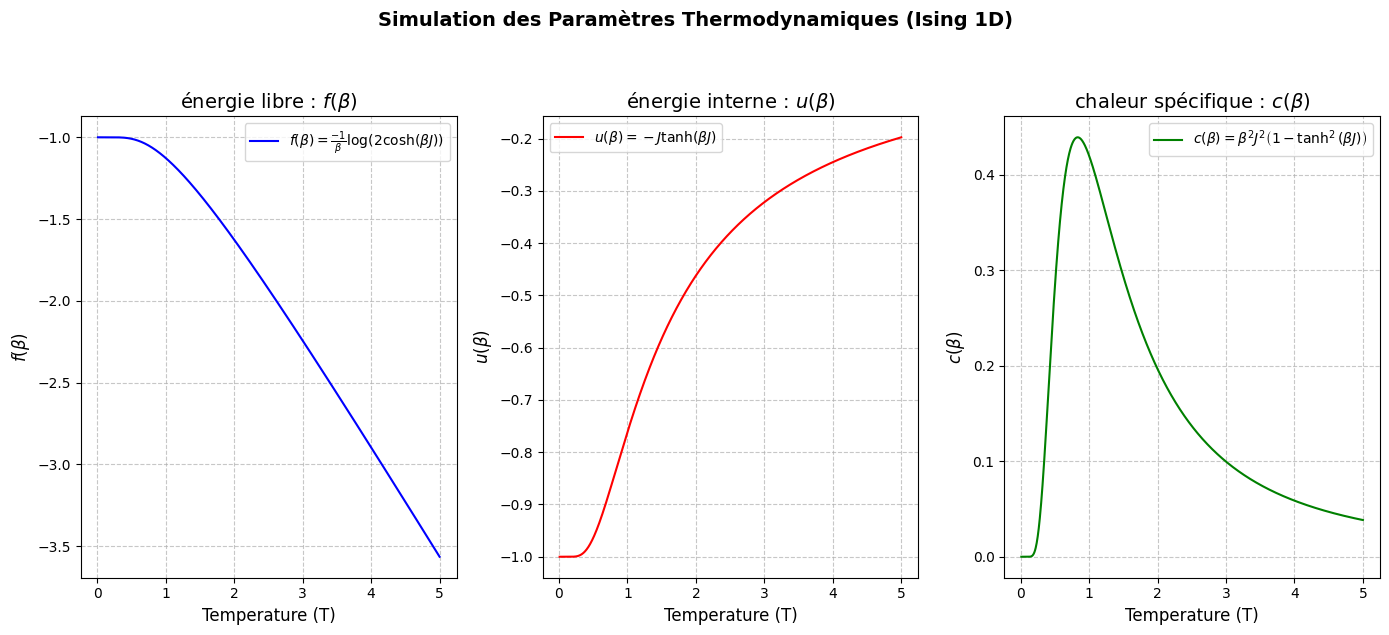

In [3]:
# Paramètres de la simulation
J = 1.0  # Constante
N = 100  # Nombre de sites étudiés
temperature_values = np.linspace(0.01, 5, 1000)  # Températures évaluées (éviter T=0 pour éviter division par zéro)
beta_values = 1 / temperature_values  # β : inverse de la température, k_b = 1

# Définir les fonctions f(β), u(β) et c(β)
def f(beta, J):
    return -1 / beta * np.log(2 * np.cosh(beta * J))

def u(beta, J):
    return -J * np.tanh(beta * J)

def c(beta, J):
    return beta**2 * J**2 * (1 - np.tanh(beta * J)**2)

# Calcul des valeurs pour f(β), u(β) et c(β)
f_values = f(beta_values, J)
u_values = u(beta_values, J)
c_values = c(beta_values, J)

# Création des sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Simulation des Paramètres Thermodynamiques (Ising 1D)', y=1.05,fontsize=14, fontweight='bold')

# Graphique 1 : f(β)
axes[0].plot(temperature_values, f_values, color='blue', label=r"$f(\beta) = \frac{-1}{\beta} \log(2 \cosh(\beta J))$")
axes[0].set_title("énergie libre : $f(\\beta)$", fontsize=14)
axes[0].set_xlabel("Temperature (T)", fontsize=12)
axes[0].set_ylabel(r"$f(\beta)$", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7) 
axes[0].legend(fontsize=10)

# Graphique 2 : u(β)
axes[1].plot(temperature_values, u_values, color='red', label=r"$u(\beta) = -J\tanh(\beta J)$")
axes[1].set_title("énergie interne : $u(\\beta)$", fontsize=14)
axes[1].set_xlabel("Temperature (T)", fontsize=12)
axes[1].set_ylabel(r"$u(\beta)$", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(fontsize=10)

# Graphique 3 : c(β)
axes[2].plot(temperature_values, c_values, color='green', label=r"$c(\beta) = \beta^2 J^2 \left( 1 -\tanh^2(\beta J) \right)$")
axes[2].set_title("chaleur spécifique : $c(\\beta)$", fontsize=14)
axes[2].set_xlabel("Temperature (T)", fontsize=12)
axes[2].set_ylabel(r"$c(\beta)$", fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.7)
axes[2].legend(fontsize=10)

# Ajustement de l'espacement entre les sous-graphiques
plt.tight_layout()

# Affichage
plt.show()

L’absence de transition de phase dans ce système peut être expliquée par la dimension du système  (1D) et les fortes fluctuations thermiques qui empêchent l’apparition d’un état ordonné. Dans un modèle d’Ising en 1D, les interactions entre spins voisins immédiats ne suffisent pas à créer une transition nette entre un état ordonné et un état désordonné, même à basse température. En 1D, l’énergie libre et la capacité thermique sont continues et ne présentent pas de singularités, contrairement aux systèmes en 2D ou 3D où des transitions de phase se produisent. Les fluctuations thermiques dominent, empêchant ainsi toute transition de phase de premier ordre.

# Part II — Simulation Monte Carlo

## Q1
Pour représenter la configuration du système de manière efficace, nous utiliserons un tableau de type bool de longueur N+2 pour inclure les spins avec les conditions aux bords fixes. On va considerer True comme +1 et False comme −1. De plus, on implémente une fonction qui mesure la distance de Hamming normalisée entre la configuration initiale et la configuration qui évolue avec le Monte Carlo.

In [4]:
# Functions 

# Variation d'énergie avec conditions aux bords
def energy_variation_1d(s: np.ndarray, J: float, pos: int, verbosity: int = 0) -> float:
    if (1>pos or pos>np.size(s)-2):
        raise ValueError("On ne peut pas modifier les conditions aux bords")
    else:
        s_i = s[pos]
        s_prev = s[pos - 1]  # Voisin gauche (périodique)
        s_next = s[pos + 1]  # Voisin droit (périodique)

    # Calcul de la variation d'énergie
    delta_E = 2 * J * s_i * (s_prev + s_next)
    
    if verbosity > 1:
        print(f"Variation d'énergie ∆E (position {pos}) : {delta_E}")

    return delta_E


# Énergie totale 
def total_energy_1d(s: np.ndarray, J: float, verbosity: int = 0) -> float:
    energy = -J * np.sum(s[:-1] * s[1:])
    if verbosity > 1:
        print(f"Énergie totale du système : {energy}")
    
    return energy


def d_Hamming(s_init_hamming: Iterable, s_hamming: Iterable, verbosity: int = 0) -> float:
    # Conversion des entrées en tableaux NumPy (si nécessaire)
    s_init_hamming = np.asarray(s_init_hamming)
    s_hamming = np.asarray(s_hamming)

    if s_hamming.shape != s_init_hamming.shape:
        raise ValueError("Les deux configurations doivent avoir la même forme.")
    
    # Calcul vectorisé
    d_H = np.sum(s_init_hamming != s_hamming) / s_hamming.size

    if verbosity > 2:
        print(f"Tableau de spins : {s_hamming}")
        print(f"Tableau de spins initiaux : {s_init_hamming}")
        print(f"Distance de Hamming : {d_H}")
    
    return d_H


# Algorithme de Metropolis (1D)
def metropolis_simulation_1d(s_init: Iterable[bool], J: float, beta: float, n_steps: int, verbosity:int = 0, sample_rate : int = 100) -> Iterable[bool]:

    spins = np.where(np.array(s_init), 1, -1)  # Tableau NumPy de 1/-1
    s_init_numeric = spins.copy() # conservation des données initiales en {1, -1}
    N = len(spins) # nombre de spins etudiés
    d_H = [] # tableau retracant l'évolution de la distance de Hamming

    for step in range(int(n_steps)):
        pos = np.random.randint(1, N-1) # Choisir un spin aléatoirement
        
        delta_E = energy_variation_1d(spins, J, pos, verbosity = 0) # Calculer la variation d'énergie
        
        if delta_E <= 0 or np.random.rand() < np.exp(-beta * delta_E):
            spins[pos] *= -1  # Retourner le spin
            if verbosity > 1:
                print(f"Étape {step + 1}/{n_steps}: Spin à la position {pos} retourné, distance de hamming : {d_Hamming(s_init_numeric, spins, 3)}")

        if step % sample_rate == 0:  # sample_rate peut être un paramètre d'entrée
            d_H.append(d_Hamming(s_init_numeric, spins)) # distance de Hamming au step

        if verbosity > 0 and (step + 1) % (n_steps // 10) == 0:
            print(f"Progression : {100 * (step + 1) // n_steps}%")

    if verbosity > 2:
        print(f"\nsystème final de spins de la simulation : {spins}")
        print(f"distance de Hamming de la simulation : {d_H}")
            
    return spins, np.array(d_H)

## Q2
Étudions maintenant la décorrélation du système en fonction de la température.


N = 100 : 
T/J = 0.001, N = 100: Transition observée à l'itération 207
T/J = 1, N = 100: Transition observée à l'itération 689
T/J = 1000, N = 100: Transition observée à l'itération 110

N = 500 : 
T/J = 0.001, N = 500: Transition observée à l'itération 3804
T/J = 1, N = 500: Transition observée à l'itération 2214
T/J = 1000, N = 500: Transition observée à l'itération 570

N = 1000 : 
T/J = 0.001, N = 1000: Transition observée à l'itération 12058
T/J = 1, N = 1000: Transition observée à l'itération 5087
T/J = 1000, N = 1000: Transition observée à l'itération 1238


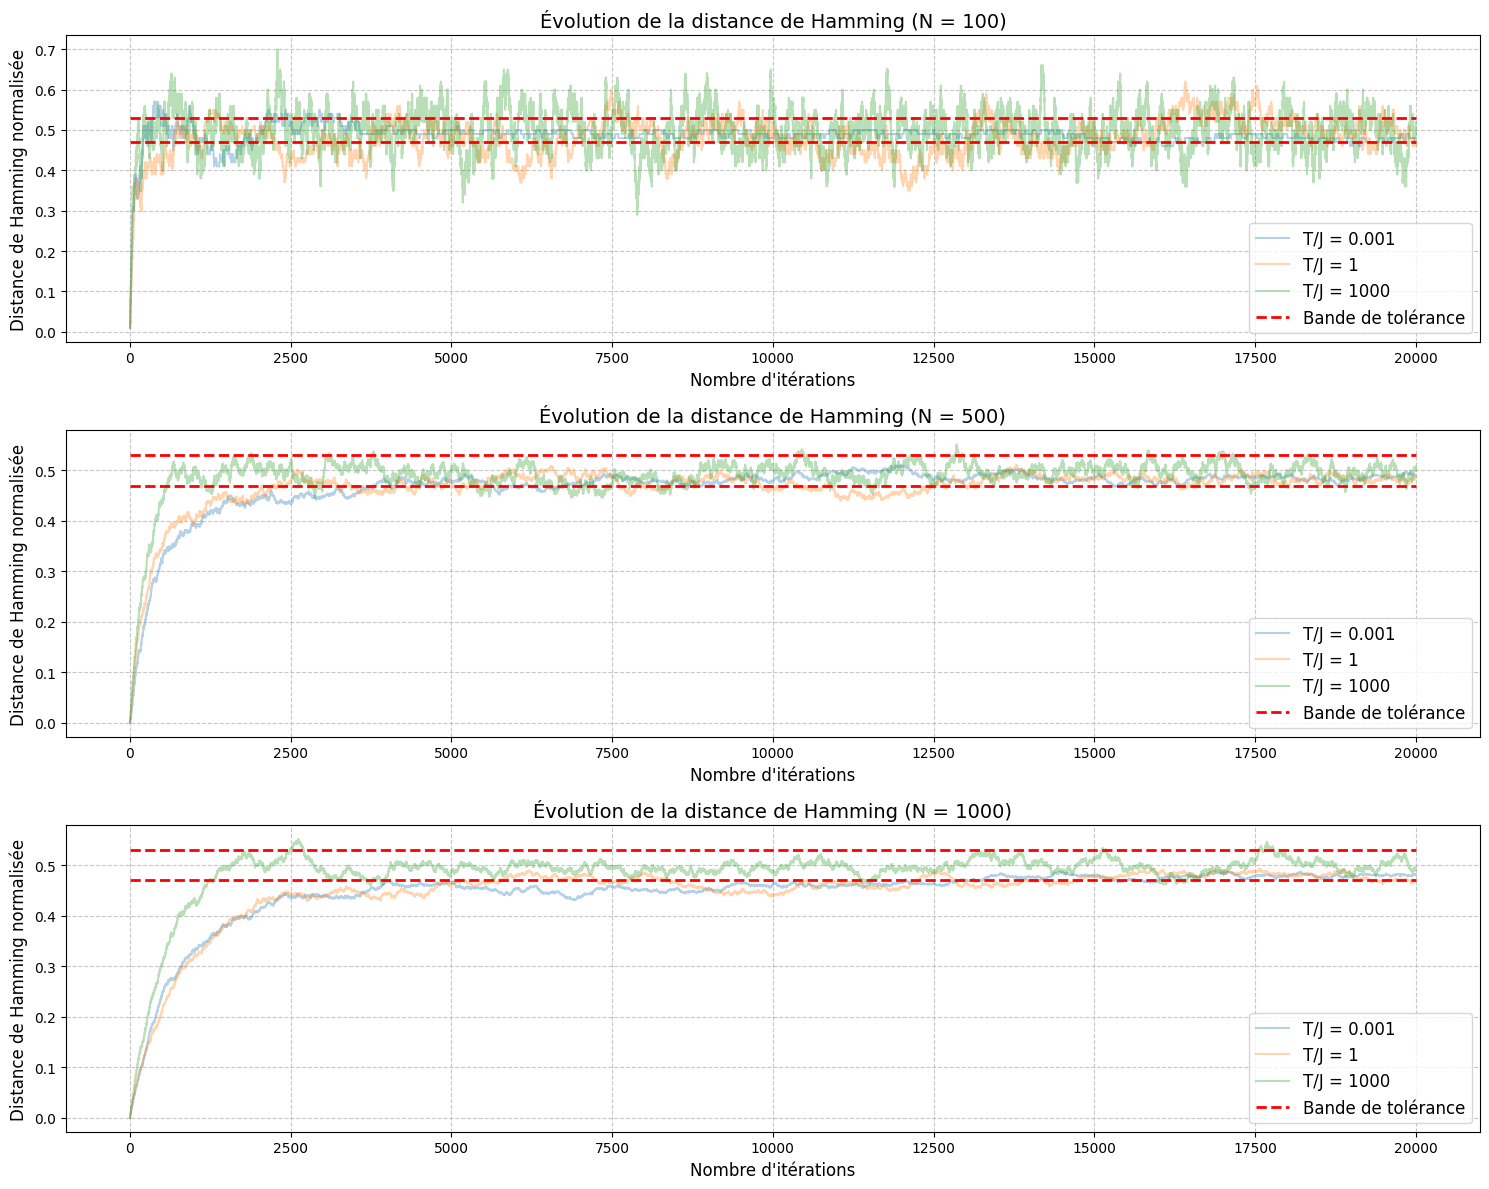

In [5]:
# Paramètres de la simulation
J = 1.0  # Constante d'échange
temperatures = [0.001, 1, 1000]  # Différentes températures
sizes = [100, 500, 1000]  # Tailles du système
n_steps = 2 * int(1e4)  # Nombre d'étapes Monte Carlo
tol = 0.03  # Tolérance pour trouver l'itération de thermalisation
threshold = 0.5  # Seuil de distance de Hamming

transition_step = [[] for _ in sizes]  # Tableau pour stocker les étapes de transition

# Fonction pour calculer beta en fonction de T
def beta_from_temperature(T, J):
    return J / T  # Corrigé pour éviter une double division inutile

plt.figure(figsize=(15, 12))

# Vérifie si transition_step existe, sinon initialise-le
if "transition_step" not in locals():
    transition_step = [[] for _ in range(len(sizes))]

# Parcourir chaque taille de système N
for i, N in enumerate(sizes):
    plt.subplot(3, 1, i + 1)

    if verbosity > 0:
        print(f"\nN = {N} : ")

    # Parcourir les températures
    for j, T in enumerate(temperatures):  
        beta = beta_from_temperature(T, J)
        
        # Initialisation aléatoire des spins
        s_init = np.random.choice([True, False], size=N)
        
        # Simulation de Metropolis 
        _, hamming_distances = metropolis_simulation_1d(s_init, J, beta, n_steps, verbosity=0, sample_rate = 1)

        # Identifier l'itération où la transition se produit
        step = next((step for step, d in enumerate(hamming_distances, start=1) if np.abs(d - threshold) < tol), n_steps)
        transition_step[i].append(step)

        if verbosity > 0:
            print(f"T/J = {T}, N = {N}: Transition observée à l'itération {step}")
        
        # Tracer les données avec une opacité proportionnelle au nombre de températures
        alpha_value = 1 / len(temperatures)
        plt.plot(
            range(1, n_steps + 1),
            hamming_distances,
            label=f"T/J = {T}",
            markevery=n_steps // 10,  # Marqueurs placés régulièrement
            alpha=alpha_value
        )

    # Configurer les axes et les légendes pour chaque sous-graphe
    plt.xlabel("Nombre d'itérations", fontsize=12)
    plt.ylabel("Distance de Hamming normalisée", fontsize=12)
    plt.title(f"Évolution de la distance de Hamming (N = {N})", fontsize=14)
    plt.hlines(
        y=[0.5 - tol, 0.5 + tol],
        xmin=1, xmax=n_steps + 1,
        colors='red',
        linestyles='--',
        linewidth=2,
        label="Bande de tolérance"
    )
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

# Ajuster la disposition et afficher les graphes
plt.tight_layout()
plt.show()

Le **temps de décorrélation** du système, noté $ n_{\text{therm}} $, correspond au nombre d'itérations nécessaires pour que le système atteigne un état indépendant des conditions initiales. Cela se manifeste lorsque la **distance de Hamming** entre les configurations devient proche de $ 0.5 $. Une tolérance est définie pour déterminer à partir de quel seuil cette distance est considérée comme suffisamment proche de $ 0.5 $ pour caractériser un système décorrélé.  

Le temps de décorrélation $ n_{\text{therm}} $ dépend des paramètres suivants :  
- la **température** du système $ T $,  
- la **taille** du système $ N $.  

On remarque que plus la température est basse ou que plus le système est grand, plus le système prend du temps à se décorreler.
Les simulations permettent d'estimer les ordres de grandeur de $ n_{\text{therm}}(T, N) $. Ainsi, il est raisonnable de considérer que la thermalisation du système est atteinte pour des tailles de système allant jusqu'à $ N = 1000 $ et des températures vérifiant $ 0.001 < T < 1000 $, avec un nombre d'itérations inférieur à $ 10^4 $.

## Q3

### a.
Afin d'étudier l'évolution de notre système, nous analysons deux métriques principales : l'énergie moyenne par spin, notée $u(\beta)$ , et la chaleur spécifique, notée $c(\beta)$. Ces métriques sont comparées entre les résultats obtenus à partir des simulations de Monte Carlo et les prédictions issues des courbes théoriques, permettant ainsi de valider ou d'ajuster notre modèle.

Simulation pour T/J = 0.10...
T/J = 0.10 (0.0%): ⟨E⟩ = -99.0000, Chaleur spécifique c = 0.0000
Simulation pour T/J = 0.14...
T/J = 0.14 (2.0%): ⟨E⟩ = -99.0000, Chaleur spécifique c = 0.0000
Simulation pour T/J = 0.18...
T/J = 0.18 (4.0%): ⟨E⟩ = -99.0000, Chaleur spécifique c = 0.0000
Simulation pour T/J = 0.22...
T/J = 0.22 (6.0%): ⟨E⟩ = -99.0000, Chaleur spécifique c = 0.0000
Simulation pour T/J = 0.26...
T/J = 0.26 (8.0%): ⟨E⟩ = -99.0000, Chaleur spécifique c = 0.0000
Simulation pour T/J = 0.29...
T/J = 0.29 (10.0%): ⟨E⟩ = -99.0000, Chaleur spécifique c = 0.0000
Simulation pour T/J = 0.33...
T/J = 0.33 (12.0%): ⟨E⟩ = -98.9800, Chaleur spécifique c = 0.0072
Simulation pour T/J = 0.37...
T/J = 0.37 (14.000000000000002%): ⟨E⟩ = -98.8200, Chaleur spécifique c = 0.0614
Simulation pour T/J = 0.41...
T/J = 0.41 (16.0%): ⟨E⟩ = -98.7200, Chaleur spécifique c = 0.0714
Simulation pour T/J = 0.45...
T/J = 0.45 (18.0%): ⟨E⟩ = -98.1600, Chaleur spécifique c = 0.1634
Simulation pour T/J = 0.49...
T

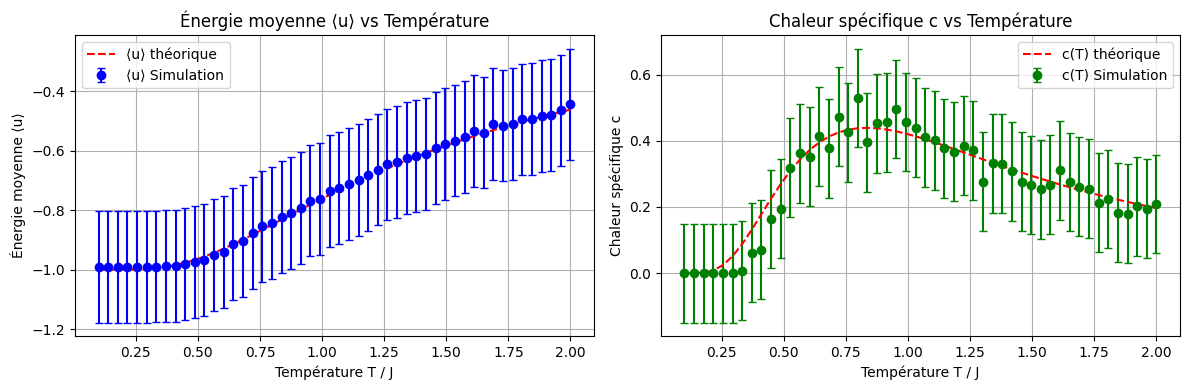

In [6]:
# Paramètres de la simulation
J = 1.0  # Constante d'échange
N = 100  # Taille du système
temperatures = np.linspace(0.1, 2, 50)  # Températures de T/J
beta_values = 1 / (temperatures / J)  # Inverse de la température
n_steps_thermalization = int(1e4)  # Nombre de pas pour la thermalisation
nbr_it = 2* int(1e2)  # Nombre d'itérations pour les mesures

# Préparer les tableaux pour les résultats
E_means_avg = np.zeros(len(temperatures))
E_var = np.zeros(len(temperatures))
specific_heats_avg = np.zeros(len(temperatures))
specific_heats_var = np.zeros(len(temperatures))

# Fonction principale
for idx, (T, beta) in enumerate(zip(temperatures, beta_values)):
    if verbosity > 0:
        print(f"Simulation pour T/J = {T:.2f}...")

    # Initialiser les accumulateurs pour ⟨E⟩ et ⟨E²⟩
    energy_accum = 0.0
    energy_squared_accum = 0.0
    energy_fourth_accum = 0.0

    for it in range(nbr_it):
        # Initialisation aléatoire des spins
        s_init = np.random.choice([-1, 1], size=N)  # Spins aléatoires en ±1
        s_init[0] = 1   # Forcer le premier spin à +1
        s_init[-1] = 1  # Forcer le dernier spin à +1
        
        # Étape de thermalisation
        s_thermalized, _ = metropolis_simulation_1d(s_init, J, beta, n_steps_thermalization, verbosity=0)

        # Calcul de l'énergie totale pour l'état thermalisé
        e = total_energy_1d(s_thermalized, J, verbosity=0)

        # Accumuler ⟨E⟩ et ⟨E²⟩
        energy_accum += e
        energy_squared_accum += e**2
        energy_fourth_accum += e**4

        # Progression
        if verbosity > 1 and (it + 1) % (nbr_it // 10) == 0:
            print(f"Progression : {100 * (it + 1) // nbr_it}%")

    E_mean = energy_accum / nbr_it
    E2_mean = energy_squared_accum / nbr_it

    # Chaleur spécifique (normalisée par N)
    specific_heat = beta**2 * (E2_mean - E_mean**2) / N

    # Stocker les résultats
    E_means_avg[idx] = E_mean / N
    specific_heats_avg[idx] = specific_heat


    if verbosity > 0:
        print(f"T/J = {T:.2f} ({idx/len(temperatures) * 100}%): ⟨E⟩ = {E_mean:.4f}, Chaleur spécifique c = {specific_heat:.4f}")

def u(beta, J):
    return -J * np.tanh(beta * J)

def c(beta, J):
    return beta**2 * J**2 * (1 - np.tanh(beta * J)**2)

E_means_std = np.std(E_means_avg)  # Écart-type pour ⟨u⟩
specific_heats_std = np.std(specific_heats_avg)  # Écart-type pour c(T)    

# Graphiques
plt.figure(figsize=(12, 4))
fig.suptitle('Comparaison des simulations Monte Carlo avec les prédictions théoriques', y=1.02, fontsize=14, fontweight='bold')

# Graphique pour ⟨E⟩
plt.subplot(1, 2, 1)
plt.errorbar(temperatures, E_means_avg, yerr=E_means_std, fmt='o', label='⟨u⟩ Simulation', color='b', capsize=3)
plt.plot(temperatures, u(beta_values, J), '--', color='red', label='⟨u⟩ théorique')
plt.xlabel('Température T / J')
plt.ylabel('Énergie moyenne ⟨u⟩')
plt.title('Énergie moyenne ⟨u⟩ vs Température')
plt.legend()
plt.grid(True)

# Graphique pour chaleur spécifique c
plt.subplot(1, 2, 2)
plt.errorbar(temperatures, specific_heats_avg, yerr=specific_heats_std, fmt='o', label='c(T) Simulation', color='g', capsize=3)
plt.plot(temperatures, c(beta_values, J), '--', color='red', label='c(T) théorique')
plt.xlabel('Température T / J')
plt.ylabel('Chaleur spécifique c')
plt.title('Chaleur spécifique c vs Température')
plt.legend()
plt.grid(True)

# Affichage des graphiques
plt.tight_layout()
plt.show()

On observe que l’énergie moyenne du système augmente avec la température, et que les simulations reproduisent fidèlement le comportement attendu à partir de l’expression analytique. De plus, la chaleur spécifique augmente jusqu’à atteindre un pic près de la température  $t = 0.75$ [K] . Les simulations reproduisent, dans les deux cas, le comportement attendu avec une bonne concordance avec les expressions numériques.

## Part III — Fonction de corrélation

## Q1

### a
La corrélation entre deux point a distance r est définie pour chaque température comme
$$ C_{\beta}(r, N) = \sum_{k = 0}^N \sum_{s_k \in \{-1,1\}} s_i s_{i+r} \frac{e^{- \beta \mathcal{H}}}{Z_\beta(N)} = \sum_{k = 0}^N \sum_{s_k \in \{-1,1\}} s_i s_{i+r}  \prod_{j = 0}^N   \frac{e^{\beta J s_j s_{j+1}}}{Z_\beta(N)} $$
En utilisant la même idée du développement haute température, on obtient :
$$ C_{\beta}(r, N) = \frac{\cosh^{N+1}(\beta J)}{Z_\beta(N)} \sum_{k = 0}^N \sum_{s_k \in \{-1,1\}} s_i s_{i+r} \prod_{j = 0}^N (1 + \kappa s_j s_{j+1}) $$
On note par ailleurs que les seuls diagrammes qui participent à la corrélation sont les diagrammes où l'on obtient $s_i^2$ et $s_{i+r}^2$ à la fin pour ne pas avoir de terme impaire. C'est à dire le diagramme où l'on a une chaîne entre $s_i$ et $s_{i+r}$ et le diagramme où l'on a deux chaines : une entre $s_0$ et $s_i$, l'autre entre $s_{i+r}$ et $s_{N}$.
On obtient alors :
$$\sum_{k = 0}^N \sum_{s_k \in \{-1,1\}} s_i s_{i+r} \prod_{j = 0}^N (1 + \kappa s_j s_{j+1}) =\sum_{k = 0}^N \sum_{s_k \in \{-1,1\}} s_i\cdot (s_is_{i+1}^2\cdots s_{i+r-1}^2s_{i+r}\kappa^r)\cdot s_{i+r} + (s_0s_1^2\cdots s_i^2)\cdot(s_{i+r}^2\cdots s_N^2 s_{N+1})\kappa^{N+1-r} = 2^N(\kappa^r+\kappa^{N+1-r})$$
où l'on a utilisé que il y a $r$ liens entre $s_i$ et $s_{i+r}$ et $N+1$ liens en tout.
Finalement, la corrélation est alors donnée par : \
$$C_{\beta}(r, N)=\frac{\cosh^{N+1}(\beta J) 2^N(\kappa^r+\kappa^{N+1-r})}{\cosh^{N+1}(\beta J)2^N(1+\kappa^{N+1})}=\frac{\kappa^r+\kappa^{N+1-r}}{1+\kappa^{N+1}}$$
### b
Pour tout $T >0$, $N \to \infty$, et $r$ fixée, la fonction de corrélation décroît exponentiellement telle que :
$$ \lim_{N \to \infty} C_{\beta}(r, N)  = \lim_{N \to \infty}  \frac{\kappa^r+\kappa^{N+1-r}}{ 1 + \kappa^{N+1} }  = \kappa^r $$
Car on rappelle que $\kappa=\tanh(\beta J)\ll 1$ dans les hautes températures.
On peut alors réécrire cela sous la forme :
$$ \kappa^r  = e^{r \ln(\kappa)} $$
On identifie alors la longueur de corrélation $\xi$ telle que :
$$ e^{r \log(\kappa)}  \approx e^{-r/\xi} \to \xi = \frac{-1}{\ln(\tanh(\beta J))}$$

## Q2

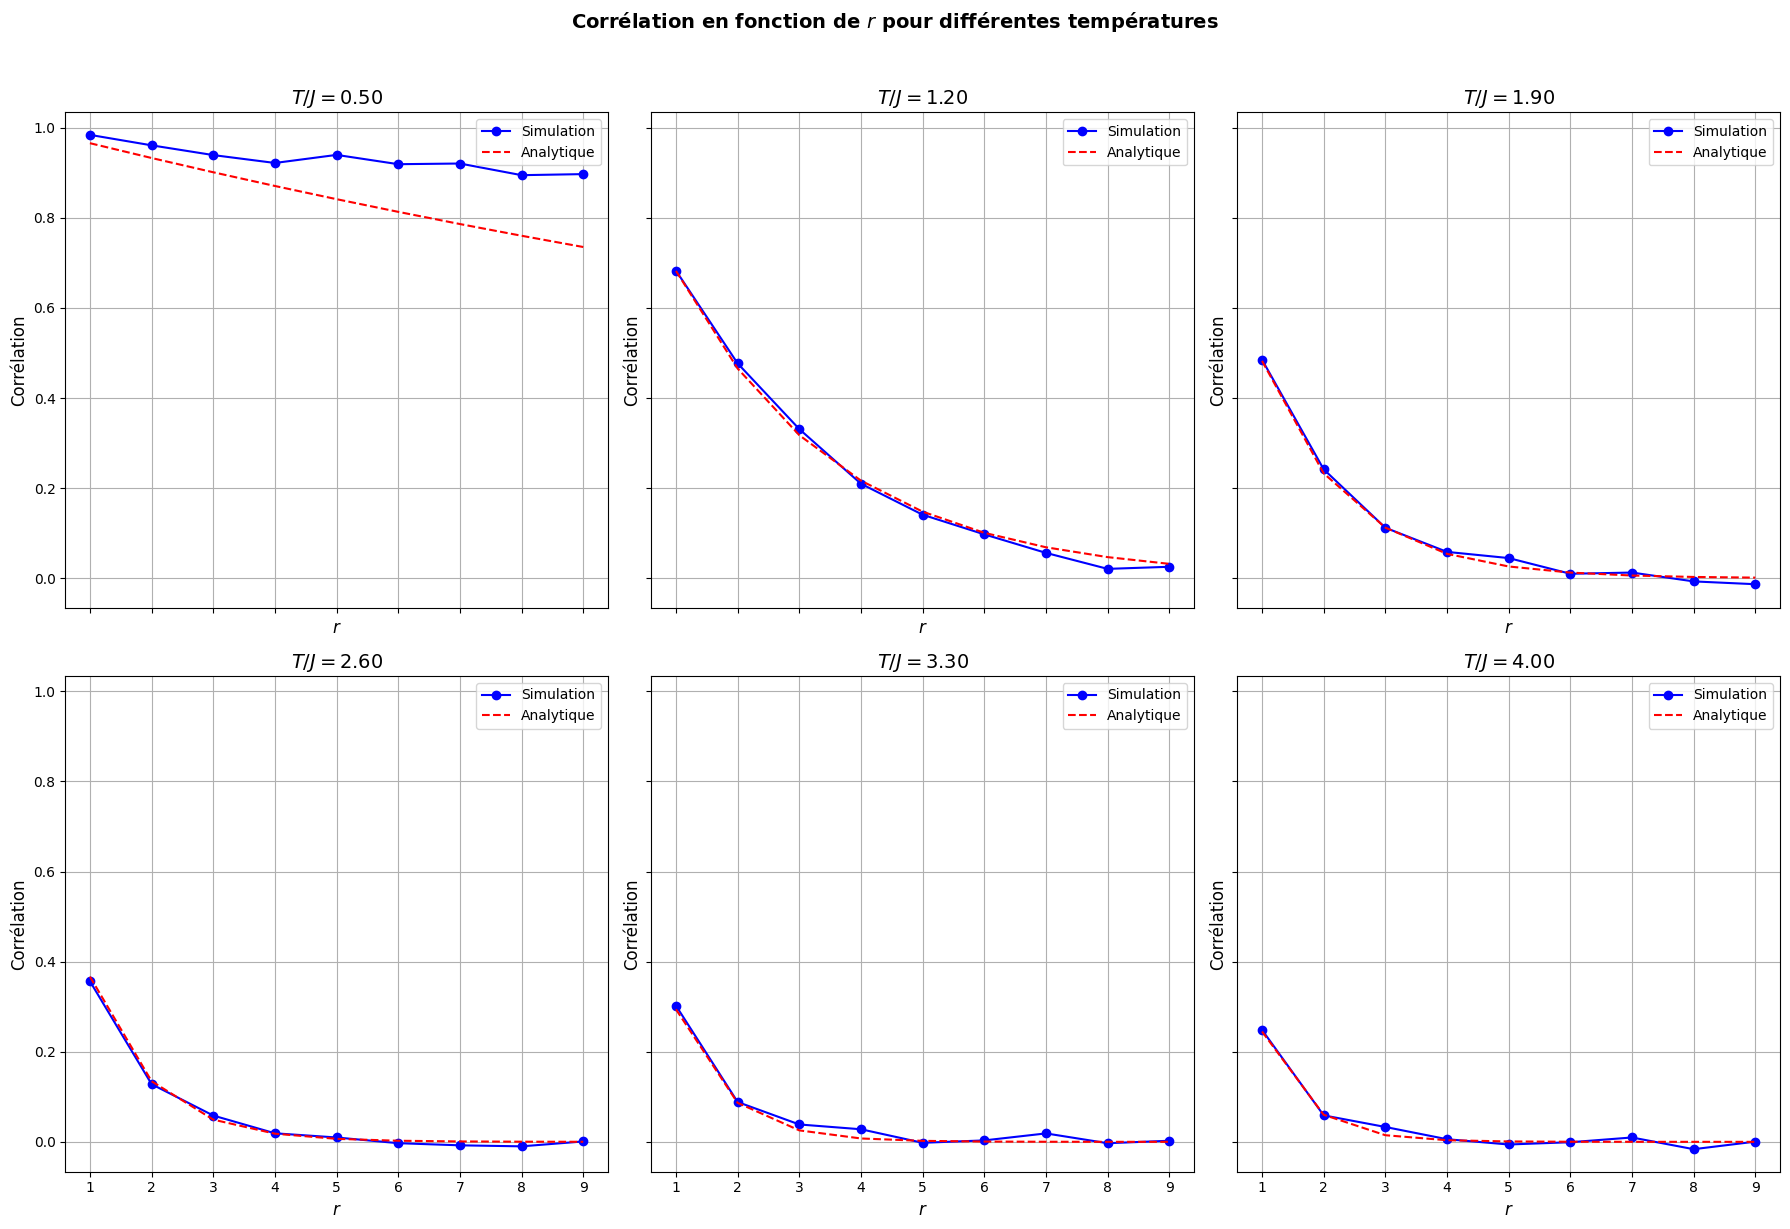

In [7]:
# Paramètres de la simulation CODE MAIL
J = 1.0 # Constante d'échange
N = 100 # Taille du système
temperatures = np.linspace(0.5, 4.0, 6) # Températures de T/J
n_steps_measurement = int(1e4) # Nombre de pas Monte Carlo pour la mesure
beta_values = 1 / (temperatures / J) # Inverses des températures
r_values = np.arange(1, N // 10) # Ensemble des distances évaluées
nbr_it = int(1e2) # Nombre d'itérations pour les mesures


# Préparer un stockage pour les corrélations
correlations_simulated = {T: [] for T in temperatures}
correlations_analytical = {T: [] for T in temperatures}
# Fonction analytique pour les corrélations
#def correlation_analytical(beta, r):
# return np.exp(r * np.log(np.tanh(beta * J))) # Solution analytique du modèle d'Ising 1D
# Fonction analytique pour les corrélations
def correlation_analytical(beta, r):
    return (np.tanh(beta * J)**(N-r+1) + np.tanh(beta * J)**(r))/(1 + np.tanh(beta * J)**(N+1)) # Solution analytique du modèle d'Ising 1D]


# Simulation pour chaque distance r
verbosity = 0
for r in r_values:
    for T, beta in zip(temperatures, beta_values):
        if verbosity > 2:
            print(f"\nSimulation pour T/J = {T}, distance r = {r}:")

        # Stocker les valeurs de corrélation pour chaque itération
        correlations_temp = []

        for _ in range(nbr_it):
        # Initialisation aléatoire des spins
            s_init = np.random.choice([True, False], size=N) * 2 - 1 # Convertir en ±1

            # Étape de thermalisation et mesure
            spins, _ = metropolis_simulation_1d(s_init, J, beta, n_steps_measurement, verbosity=0)

            # Calcul de la corrélation empirique ⟨s_i s_{i+r}⟩
            correlation = np.mean(spins[:N-r] * spins[r:])
            correlations_temp.append(correlation)

        # Moyenne empirique sur `nbr_it` itérations
        correlation_avg = np.mean(correlations_temp)
        correlations_simulated[T].append(correlation_avg)


        # Calcul de la corrélation analytique
        corr_analytic = correlation_analytical(beta, r)
        correlations_analytical[T].append(corr_analytic)


        # Affichage des résultats
        if verbosity > 2:
            print(f"T/J = {T:.2f}, r = {r}: Simulation moyenne = {correlation_avg:.4f}, Analytique = {corr_analytic:.4f}")


    # Progression
    if verbosity > 1 and (r + 1) % max(1, len(r_values) // 10) == 0:
        print(f"Progression : {100 * r // len(r_values)}%")




# Création des subplots
n_cols = 3 # Nombre de colonnes dans les subplots
n_rows = (len(temperatures) + n_cols - 1) // n_cols # Nombre de lignes nécessaires
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), sharex=True, sharey=True)
fig.suptitle('Corrélation en fonction de $r$ pour différentes températures', y=1.02, fontsize=14, fontweight='bold')


# Tracé des corrélations pour chaque température
for idx, T in enumerate(temperatures):
    ax = axes[idx // n_cols, idx % n_cols] # Localisation du subplot
    ax.plot(r_values, correlations_simulated[T], 'o-', label="Simulation", color='blue')
    ax.plot(r_values, correlations_analytical[T], '--', label="Analytique", color='red')
    ax.set_title(f"$T/J = {T:.2f}$", fontsize=14)
    ax.set_xlabel(r"$r$", fontsize=12)
    ax.set_ylabel("Corrélation", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True)


# Supprimer les axes vides si le nombre de subplots n'est pas exact
for idx in range(len(temperatures), n_rows * n_cols):
    fig.delaxes(axes.flatten()[idx])

# Ajuster l'espacement entre les subplots
plt.tight_layout()
plt.show()

On observe qu'à basse température, le système est fortement corrélé. Cela s'explique par le fait qu'il n'a pas eu suffisamment de temps pour s'éloigner de son niveau d'énergie initial, où tous les spins sont alignés (soit tous "up", soit tous "down"). Lorsque la température est basse, le modèle évolue très peu, voire pas du tout, à mesure que la température tend vers zéro. On remarque également que les résultats du modèle sont parfois encore moins corrélés que ceux prédits par la théorie.

# Exercise 2 Ising 2D

Le Hamiltonien est donné par :
$$H = -J \sum_{i=1}^{N-1} \sum_{j=1}^{N-1} \left( s_{i,j} s_{i+1,j} + s_{i,j} s_{i,j+1} \right) 
- J \sum_{i=1}^{N-1} \left( s_{N,i} s_{N,i+1} + s_{i,N} s_{i+1,N} \right) 
+ C \left( \{ s_{i,j} \}_{i,j=1}^N \right)
$$

où $ J $ est la constante de couplage entre spins voisins (avec $ J > 0 $ pour un cas ferromagnétique), et $ C $ est le terme concernant les conditions aux bords. Pour ce problème, nous considérons des conditions aux bords toroïdales (périodiques).

Le terme $ C $ est défini par :

$$
C \left( \{ s_{i,j} \}_{i,j=1}^N \right) = -J \sum_{i=1}^N \left( s_{i,N} s_{i,1} \right)  -J \sum_{i=1}^N \left( s_{N,i} s_{1,i} \right) = -J \sum_{i=1}^N \left( s_{i,N} s_{i,1} + s_{N,i} s_{1,i} \right)
$$

## Part I - Développement haute température

## Q1


### a.
On peux alors réécrire la fonction de partition du système $Z_N(\beta)$ comme :
$$ Z_N(\beta) = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} e^{-\beta \mathcal{H} } = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} e^{\beta \left( J \sum_{i=1}^{N-1} \sum_{j=1}^{N-1} \left( s_{i,j} s_{i+1,j} + s_{i,j} s_{i,j+1} \right) + J \sum_{i=1}^{N-1} \left( s_{N,i} s_{N,i+1} + s_{i,N} s_{i+1,N} \right) + J \sum_{i=1}^N \left( s_{i,N} s_{i,1} + s_{N,i} s_{1,i} \right) \right)}$$

On utilise l'identitée sur chaque terme : $e^{\beta x} = \cosh(\beta) (1 + x \tanh(\beta))$

le premier terme donne : (ici on ne separe par la somme en un produit de somme, on marque la somme juste pour montrer la factorisation du cosinus hyperbolique )
$$ \begin{aligned}
& \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} e^{\beta J \sum_{i=1}^{N-1} \sum_{j=1}^{N-1} \left( s_{i,j} s_{i+1,j} + s_{i,j} s_{i,j+1} \right)} \\
& = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N-1} \prod_{j = 1}^{N-1} e^{\beta J  \left( s_{i,j} s_{i+1,j} + s_{i,j} s_{i,j+1} \right)} \\ 
& = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N-1} \prod_{j = 1}^{N-1} \cosh(\beta J)^2 (1 +s_{i,j} s_{i+1,j}\tanh(\beta J))(1 + s_{i,j} s_{i,j+1} \tanh(\beta J ))) \\
& = \cosh(\beta J)^{2(N-1)(N-1)} \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N-1} \prod_{j = 1}^{N-1}  (1 + (s_{i,j} s_{i+1,j} + s_{i,j} s_{i,j+1}) \kappa + s_{i,j} s_{i+1,j}s_{i,j} s_{i,j+1}\kappa^2) \\
\end{aligned}$$

le second terme donne :
$$ \begin{aligned}
& \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} e^{\beta J \sum_{i=1}^{N-1} \left( s_{N,i} s_{N,i+1} + s_{i,N} s_{i+1,N} \right)} \\
& = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N-1} e^{\beta J \left( s_{N,i} s_{N,i+1} + s_{i,N} s_{i+1,N} \right)} \\
& = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N-1} \cosh^2(\beta J) (1 + s_{N,i} s_{N,i+1}\tanh(\beta J ))(1 + s_{i,N} s_{i+1,N} \tanh(\beta J ))\\
& = \cosh(\beta J)^{2(N-1)} \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N-1} (1+(s_{N,i} s_{N,i+1}+s_{i,N} s_{i+1,N})\kappa + s_{N,i} s_{N,i+1}s_{i,N} s_{i+1,N}\kappa^2)\\
\end{aligned}$$

le troisième terme : 
$$ \begin{aligned}
& = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} e^{\beta J \sum_{i=1}^N \left( s_{i,N} s_{i,1} + s_{N,i} s_{1,i} \right)} \\
& = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N} e^{\beta J \left( s_{i,N} s_{i,1} + s_{N,i} s_{1,i} \right)} \\
& = \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N} \cosh^2(\beta J) (1 + s_{i,N} s_{i,1}\tanh(\beta J ))(1 + s_{N,i} s_{1,i}\tanh(\beta J ))\\
& = \cosh(\beta J)^{2N}\sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{i = 1}^{N} (1 + (s_{i,N} s_{i,1} + s_{N,i} s_{1,i} )\kappa+s_{i,N} s_{i,1}s_{N,i} s_{1,i}\kappa^2)\\
\end{aligned}$$

On peut ainsi rassembler tout les termes, on obtient :
$$
Z_N(\beta) =  \cosh(\beta J)^{2(N-1)(N-1) + 2N + 2(N-1)} \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} 
$$
$$
\left[  \prod_{i = 1}^{N-1} \prod_{j = 1}^{N-1}  (1 + (s_{i,j} s_{i+1,j} +  s_{i,j} s_{i,j+1}) \kappa + s_{i,j} s_{i+1,j}s_{i,j} s_{i,j+1}\kappa^2)  \prod_{i = 1}^{N-1} (1+(s_{N,i} s_{N,i+1}+s_{i,N} s_{i+1,N})\kappa +  
s_{N,i} s_{N,i+1}s_{i,N} s_{i+1,N}  \kappa^2)\prod_{i = 1}^{N}(1 + (s_{i,N} s_{i,1} + s_{N,i} s_{1,i} )\kappa+s_{i,N} s_{i,1}s_{N,i} s_{1,i}\kappa^2) \right] 
$$


On peut simplifier l'écriture de la fonction de partition, en reconnaissant que cet Hamiltonien décrit un interaction entre les voisins qui peut être factorisé sous forme d'un produit entre tous les voisins.

Pour mieux visulaliser graphiquement comment ce produit représente les voisins un schéma est fourni :

![illustration](./assets/illu_12.png)


$$ Z_N(\beta) =  \cosh(\beta J)^{2N^2 - 4N + 2 + 2N + 2N- 2} \sum_{k = 1}^{N^2} \sum_{s_k \in \{-1, 1\}} \prod_{(i, j) \sim (i', j')} (1 + \kappa s_{i,j} s_{i',j'})$$
$$ Z_N(\beta) =  \cosh(\beta J)^{2N^2} \sum_{\{s_{i,j}\}} \prod_{(i, j) \sim (i', j')} (1 + \kappa s_{i,j} s_{i',j'}) $$


On pose la notation : $\kappa = \tanh(\beta J)$



#### Q1b)

De la même manière qu'au modèle en 1 dimension le produit représente tous les voisins sur le résaux de spins 2D.

Le produit $\prod_{(i, j) \sim (i', j')} (1 + \kappa s_{i,j} s_{i',j'})$ peut se développer en :
$$
    1 + \kappa \sum _{i,j} s_{i,j} s_{i+1, j+1} + \kappa^2 \sum _{(i,j)\neq (k,l)} s_{i,j} s_{i+1, j+1} s_{k,l} s_{k+1, l+1} + \kappa^3 \sum _{(i,j)\neq (k,l)\neq (m,n)} s_{i,j} s_{i+1, j+1} s_{k,l} s_{k+1, l+1} s_{m,n} s_{m+1, n+1} + \dots
$$



#### Q1c)
On voit également que pour un diagramme donnée la somme sur les configurations est nulle sauf si chaque site est relié à un site paire de lien car :
$$\sum_{\{s\}} s_{i}^{n_i} s_{j}^{n_j} s_{k}^{n_k} \cdots  = 
\begin{cases}
2^N, & \text{si tous les } n_i \text{ sont pairs} \\
0, & \text{sinon}
\end{cases}
$$
Ainsi, comme le montre cette équation on va s'intéresser seulement au diagramme fermé car dans ce cas chaque site est relié à un nombre paire de lien.

Finallement la fonction de partition peut s'écrire telle que :
$$ Z_N(\beta) = \cosh^{2N^2}(\beta J)2^{N^2} \left[ 1 + N^2 \kappa^4 + 2 N^2 \kappa^6 + \left(7 N^2 + \frac{N^2 \left(N^2 - 5\right)}{2}\right) \kappa^8 + 2N^2 \left( 6 + N^2\right) \kappa^{10} + \mathcal{O}\left(\kappa^{12}\right)\right]$$
$$ Z_N(\beta) = \cosh^{2N^2}(\beta J)2^{N^2} \left[ 1 + N^2 \kappa^4 + 2 N^2 \kappa^6 + \left(\frac{9}{2} N^2 + \frac{1}{2}N^4\right) \kappa^8 + \left( 12N^2 + 2N^4\right) \kappa^{10} + \mathcal{O}\left(\kappa^{12}\right)\right] $$

## Q2
On s’intéresse maintenant à calculer des observables comme l’énergie libre du système, l’énergie par site et la chaleur spécifique.

### a
On s'interesse d'abord à l’énergie libre par site dans la limite thermodynamique (ordre $\kappa^{10}$):
$$f(\beta) = - \lim_{N \to \infty} \frac{1}{\beta N^2} \log \left( Z_N (\beta) \right)$$
$$f(\beta) = - \lim_{N \to \infty} \frac{1}{\beta N^2} \log \left( \cosh^{2N^2}(\beta J)2^{N^2} \left[ 1 + N^2 \kappa^4 + 2 N^2 \kappa^6 + \left(\frac{9}{2} N^2 + \frac{1}{2}N^4\right) \kappa^8 + \left( 12N^2 + 2N^4\right) \kappa^{10} + \mathcal{O}\left(\kappa^{12}\right)\right] \right)$$ 
On peut alors décomposer le logarithme tel que :
$$= - \lim_{N \to \infty} \frac{1}{\beta N^2} \left( \log \left( \cosh^{2N^2}(\beta J)2^{N^2} \right) + \log \left( 1 + N^2 \kappa^4 + 2 N^2 \kappa^6 + \left(\frac{9}{2} N^2 + \frac{1}{2}N^4\right) \kappa^8 + \left( 12N^2 + 2N^4\right) \kappa^{10}  + \mathcal{O}\left(\kappa^{12}\right) \right) \right)$$ 
Le premier therme du logarithme peut s'écrire :
$$ \log \left( \cosh^{2N^2}(\beta J)2^{N^2} \right) = \log \left( \cosh^{2N^2}(\beta J) \right) + \log \left(2^{N^2} \right) = N^2 \left(\log \left( \cosh^{2}(\beta J) \right) + \log \left(2 \right) \right)$$
Le second terme logarithmique est :
$$ \log \left( 1 + N^2 \kappa^4 + 2 N^2 \kappa^6 + \left(\frac{9}{2} N^2 + \frac{1}{2}N^4\right) \kappa^8 + \left( 12N^2 + 2N^4\right) \kappa^{10} + \mathcal{O}\left(\kappa^{12}\right) \right) $$
On utilise l'approximation : $\log (1 + x) = x - \frac{1}{2} x^2 + \frac{1}{3} x^3 + ... $ où l'on garde uniquement les terme d'ordre inférieur ou égal à $\kappa^{10}$

où $x = N^2 \kappa^4 + 2 N^2 \kappa^6 + \left(\frac{9}{2} N^2 + \frac{1}{2}N^4\right) \kappa^8 + \left( 12N^2 + 2N^4\right) \kappa^{10} + \mathcal{O}\left(\kappa^{12}\right)$

En développant, on obtient :
$$ \begin{aligned}
&\log \left( 1 + N^2 \kappa^4 + 2 N^2 \kappa^6 + \left(\frac{9}{2} N^2 + \frac{1}{2}N^4\right) \kappa^8 + \left( 12N^2 + 2N^4\right) \kappa^{10} + \mathcal{O}\left(\kappa^{12}\right) \right)\\
&\approx N^2\left( \kappa^4 + 2 \kappa^6 + \frac{9}{2} \kappa^8  + \frac{1}{2}N^2 \kappa^8 +  12 \kappa^{10} + 2N^2 \kappa^{10} \right) - \frac{N^4}{2}\left(\kappa^8 + 2 \times 2 \kappa^{4+6}\right)\\
&\approx N^2\left( \kappa^4 + 2 \kappa^6 + \frac{9}{2}  \kappa^8 +  12 \kappa^{10} \right)\\
\end{aligned} $$

D'autre part, on peut aussi développer le terme : $\cosh^2(\beta J) \approx \frac{1}{1 - \kappa^2} \approx 1 + \kappa^2 + \kappa^4 + \kappa^6 ...$. 

Ainsi, on peur exprimer le terme : $\log(\cosh^2(\beta J))$ à l'ordre $10$ tel que :
$$\log(\cosh^2(\beta J)) $$
$$\begin{aligned} & = \log( 1 + \kappa^2 + \kappa^4 + \kappa^6 + \kappa^8 + \kappa^{10} + \mathcal{O}(\kappa^{12})) \\
& = \kappa^2 + \kappa^4 + \kappa^6 + \kappa^8 + \kappa^{10} - \frac{(\kappa^2 + \kappa^4 + \kappa^6 + \kappa^8 + \kappa^{10})^2}{2} +  \frac{(\kappa^2 + \kappa^4 + \kappa^6 + \kappa^8 + \kappa^{10})^3}{3} + ...\\
& = \kappa^2 + \kappa^4 + \kappa^6 + \kappa^8 + \kappa^{10} - \frac{\kappa^{2^2}}{2} - \frac{\kappa^{4^2}}{2} - \frac{2\kappa^{2 + 4}}{2} - \frac{2\kappa^{2 + 6}}{2} - \frac{2\kappa^{2 + 8}}{2} - \frac{2\kappa^{6 + 4}}{2} + \frac{\kappa^{2^3}}{3} + \frac{3 \kappa^{2 \cdot 2+4}}{3} + \frac{3 \kappa^{4\cdot 2+2}}{3} + \frac{3 \kappa^{2 \cdot 2+6}}{3} - \frac{\kappa^{2^4}}{4} - \frac{4 \kappa^{2 \cdot 3 + 4}}{4} + \frac{\kappa^{10}}{5} + ...\\
& = \kappa^2 + \frac{1}{2}\kappa^4 + \frac{1}{3}\kappa^6 + \frac{1}{4} \kappa^8 + \frac{1}{5} \kappa^{10}  + \mathcal{O}(\kappa^{12}) \\
\end{aligned}$$

On peut rassembler l'ensemble des termes afin d'obtenir :
$$f(\beta) = - \lim_{N \to \infty} \frac{1}{\beta N^2} \left(  N^2\left( \kappa^4 + 2 \kappa^6 + \frac{9}{2}  \kappa^8 +  12 \kappa^{10} \right) + N^2 \log(2) + N^2 \left( \kappa^2 + \frac{1}{2}\kappa^4 + \frac{1}{3}\kappa^6 + \frac{1}{4} \kappa^8 + \frac{1}{5} \kappa^{10}  + \mathcal{O}(\kappa^{12}) \right) \right)$$
$$f(\beta) = - \frac{1}{\beta } \left( \log(2) + \kappa^2 + \frac{3}{2} \kappa^4 + \frac{7}{3} \kappa^6 + \frac{19}{4}\kappa^8 + \frac{61}{5}\kappa^{10} + \mathcal{O}(\kappa^{12}) \right)$$


### b
On commence par dériver l'énergie interne : $u(\beta) = \frac{\partial \beta f}{\partial \beta}$
$$ \begin{aligned}
&=  \frac{\partial \beta f}{\partial \beta} \\
&= - \partial_\beta \left( \log(2) + \kappa^2 + \frac{3}{2} \kappa^4 + \frac{7}{3} \kappa^6 + \frac{19}{4}\kappa^8 + \frac{61}{5}\kappa^10 + \mathcal{O}(\kappa^{12})\right) \\
&= - J (1 - \kappa^2)\left( 2 \kappa + \frac{3}{2} 4 \kappa^3 + \frac{7}{3} 6  \kappa^5 + \frac{19}{4} 8 \kappa^7 + \frac{61}{5} 10 \kappa^9\right) \\
&= - 2J \left( \kappa +3 \kappa^3 + 7  \kappa^5 + 19 \kappa^7 + 61 \kappa^9 - \kappa^3 - 3 \kappa^5 - 7 \kappa^7 - 19 \kappa^9 - 61 \kappa^{11} \right) \\
&= - 2J \left( \kappa +2 \kappa^3 + 4  \kappa^5 + 12 \kappa^7 + 42 \kappa^9 + \mathcal{O}(\kappa^{11}) \right) \\
\end{aligned}$$
Où l'on rappel la dérivée : $\partial_\beta \kappa^n = n J (1 - \kappa^2) k^{n-1}$

Ensuite, on dérive la chaleur spécifique : $c(\beta) = - \beta^2 \frac{\partial^2 \beta f}{\partial^2 \beta} =  - \beta^2 \frac{\partial u(f)}{\partial \beta} $
$$ \begin{aligned}
&=   - \beta^2 \frac{\partial u(f)}{\partial \beta} \\
&= 2 \beta^2 J^2 (1 - \kappa^2) \left( 1 + 6 \kappa^2 + 20 \kappa^4 + 84 \kappa^6 + 378 \kappa^8 - 671 \kappa^{10} \right) \\
\end{aligned}$$

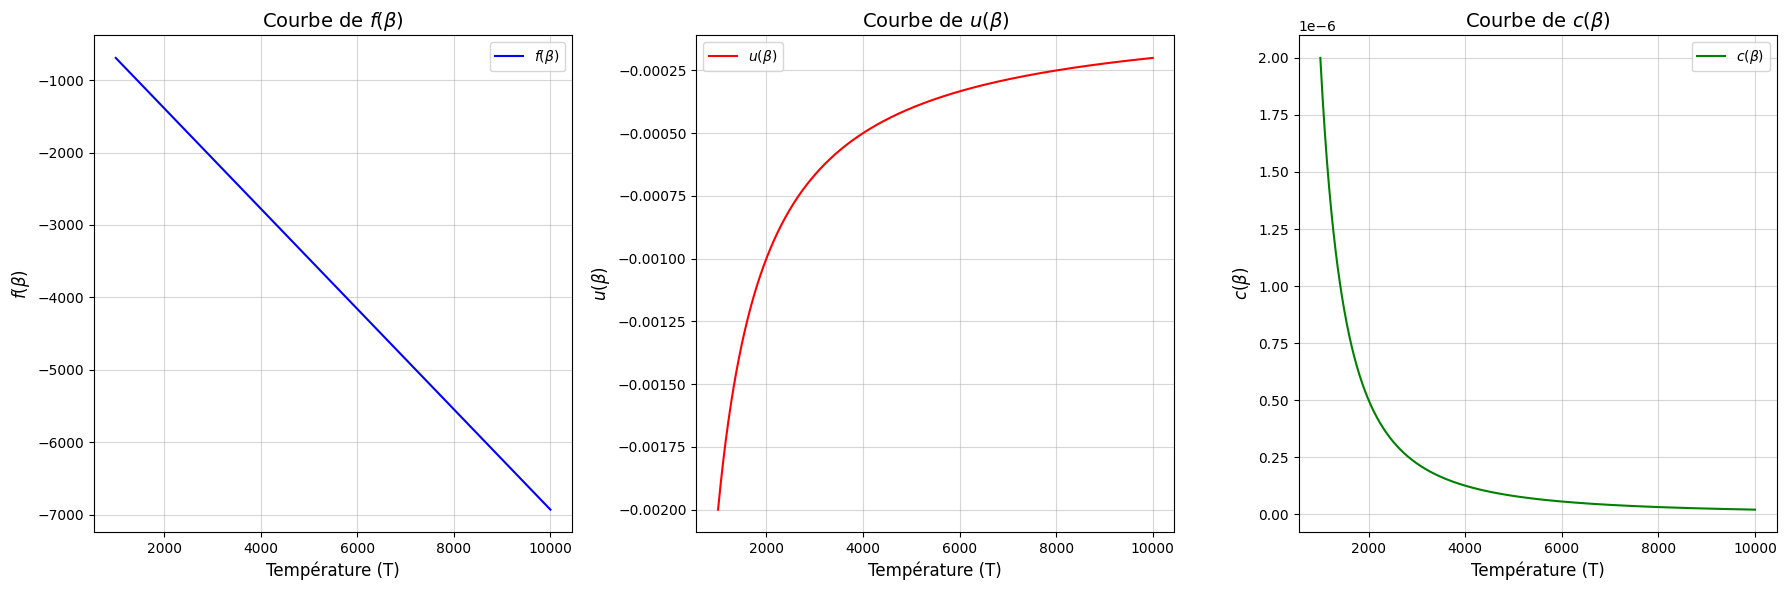

In [8]:
# Paramètres de la simulation
J = 1.0  # Constante d'interaction
N = 100  # Nombre de sites étudiés
temperature_values = np.linspace(1000, 10000, 1000)  # Températures évaluées (éviter T=0 pour éviter division par zéro)
beta_values = 1 / temperature_values  # β : inverse de la température

# Définitions des fonctions
def kappa(beta, J):
    return np.tanh(beta * J)

def f(beta, J):
    return -1 / beta * (
        np.log(2) 
        + kappa(beta, J)**2 
        + 3/2 * kappa(beta, J)**4 
        + 7/3 * kappa(beta, J)**6 
        + 19/4 * kappa(beta, J)**8 
        + 61/5 * kappa(beta, J)**10
    )

def u(beta, J):
    return -2 * J * (
        kappa(beta, J) 
        + 2 * kappa(beta, J)**3 
        + 4 * kappa(beta, J)**5 
        + 12 * kappa(beta, J)**7 
        + 42 * kappa(beta, J)**9
    )

def c(beta, J):
    return 2 * beta**2 * J**2 * (
        1
        + 6 * kappa(beta, J)**2
        + 20 * kappa(beta, J)**4 
        + 84 * kappa(beta, J)**6 
        + 378 * kappa(beta, J)**8
        - 671 * kappa(beta, J)**8
    )

# Calcul des valeurs pour f(β), u(β) et c(β)
f_values = f(beta_values, J)
u_values = u(beta_values, J)
c_values = c(beta_values, J)

# Création des sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Graphique 1 : f(β)
axes[0].plot(temperature_values, f_values, color='blue', label=r"$f(\beta)$")
axes[0].set_title("Courbe de $f(\\beta)$", fontsize=14)
axes[0].set_xlabel("Température (T)", fontsize=12)
axes[0].set_ylabel(r"$f(\beta)$", fontsize=12)
axes[0].grid(alpha=0.5)
axes[0].legend(fontsize=10)

# Graphique 2 : u(β)
axes[1].plot(temperature_values, u_values, color='red', label=r"$u(\beta)$")
axes[1].set_title("Courbe de $u(\\beta)$", fontsize=14)
axes[1].set_xlabel("Température (T)", fontsize=12)
axes[1].set_ylabel(r"$u(\beta)$", fontsize=12)
axes[1].grid(alpha=0.5)
axes[1].legend(fontsize=10)

# Graphique 3 : c(β)
axes[2].plot(temperature_values, c_values, color='green', label=r"$c(\beta)$")
axes[2].set_title("Courbe de $c(\\beta)$", fontsize=14)
axes[2].set_xlabel("Température (T)", fontsize=12)
axes[2].set_ylabel(r"$c(\beta)$", fontsize=12)
axes[2].grid(alpha=0.5)
axes[2].legend(fontsize=10)

# Ajustement de l'espacement entre les sous-graphiques
plt.tight_layout()

# Affichage
plt.show()

## Part II - Développement basse température

## Q1

### a 

Dans la limite de basse température ($\beta \to \infty$), l’état fondamental du système est celui avec l’énergie la plus faible, car la probabilité d’occupation des niveaux d’énergie excités diminue exponentiellement avec $\beta E$, où $E$ est l’énergie d’un état donné. Dans cette limite et sous conditions aux bords périodiques, les configurations où tous les spins sont uniformément alignés, soit à +1, soit à -1, correspondent aux états d’énergie minimale.\
Ces états sont en compétition avec d’autres configurations possibles (par exemple, des états avec des spins partiellement alignés), mais la probabilité de présence de ces autres états devient négligeable à très basse température. Le système cherche donc à minimiser son énergie totale, ce qui le pousse à adopter un état fondamental avec des spins entièrement alignés. 

### b

L'énergie de l'état fondamentale est alors :
$$E_0 = E(T \to 0) = - 2 J N^2$$

### c

On peut alors expliciter les trois premières excitations possibles au-dessus de l’état fondamental (notées ici $E_1, E_2, E_3$):

$E_1$ : Un spin est non-aligné avec le reste du réseau. Tous les spins peuvent faire ce retournement et cela produit une dégénéressance de $N^2$. On a alors quatre laisons qui produisent une énergie $\kappa$.

<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-evenly;">
    <img src="./assets/illu_6.png" alt="illustration" width="300" height="200">
</div>

$E_2$ : On a 6 liaisons qui interagissent et ca peut se produire dans différents cas. On peut avoir deux spins colés verticalement ou horizontalement. On trouve une dégénéressance de $2N^2$.

<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-evenly;">
    <img src="./assets/illu_7.png" alt="illustration" width="300" height="200">
</div>

$E_3$ : On a 8 liaisons qui interagissent. On obtient $7$ configurations differentes ou 3 spins sont alignés et on a le cas ou deux spins ne sont pas colés et cela produit 2 fois 4 laisions. la degenerance du systeme est donc de $\frac{N(N-5)}{2}$

<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-evenly;">
    <img src="./assets/illu_8.png" alt="illustration" width="300" height="200">
    <img src="./assets/illu_9.png" alt="illustration" width="300" height="200">
</div>

$E_4$ : On a 10 liaisons qui interagissent. On note alors directement sur les schémas le nombre de combinaisons possibles pour chaque configurations. (On met le quatrième niveau d'énergie ici pour justifier les coefficients devant les terme d'ordre 10)

<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-evenly;">
    <img src="./assets/illu_10.png" alt="illustration" width="300" height="200">
    <img src="./assets/illu_11.png" alt="illustration" width="300" height="200">
</div>




## Q2

### a.

La fonction de partition $Z_N(\beta)$ à basse température peut s’écrire comme :
$$ Z_N(\beta) = \sum_{k = 0}^N \sum_{s_k \in \{-1, 1\}} e^{\beta \mathcal{H} } = \sum_{k = 0}^N \sum_{s_k \in \{-1, 1\}} e^{\beta \left( J \sum_{i=1}^{N-1} \sum_{j=1}^{N-1} \left( s_{i,j} s_{i+1,j} + s_{i,j} s_{i,j+1} \right) + J \sum_{i=1}^{N-1} \left( s_{N,i} s_{N,i+1} + s_{i,N} s_{i+1,N} \right) + J \sum_{i=1}^N \left( s_{i,N} s_{i,1} + s_{N,i} s_{1,i} \right) \right)}$$
On peut mettre en evidence l'état fondamental : 
$$ \begin{aligned}
& = e^{N^2J\beta} \sum_{k = 0}^N \sum_{s_k \in \{-1, 1\}} e^{ N^2J\beta - \beta \left( J \sum_{i=1}^{N-1} \sum_{j=1}^{N-1} \left( s_{i,j} s_{i+1,j} + s_{i,j} s_{i,j+1} \right) + J \sum_{i=1}^{N-1} \left( s_{N,i} s_{N,i+1} + s_{i,N} s_{i+1,N} \right) + J \sum_{i=1}^N \left( s_{i,N} s_{i,1} + s_{N,i} s_{1,i} \right) \right)} \\
& = e^{N^2J\beta} \times \left[  1 + N^2 \left( e^{-2 \beta J} \right)^{4} + 2 N^2 \left( e^{-2 \beta J} \right)^{6} + \left( \frac{N^2(N^2-5)}{2} + 7N^2\right)\left( e^{-2 \beta J} \right)^{8}  + 2N^2 (N^2 + 6) \left( e^{-2 \beta J} \right)^{10} + \mathcal{O}(e^{-20\beta J})\right] \\
\end{aligned}$$

On peut alors réécrire la fonction de partition comme :
$$ Z_N(\beta) = e^{-\beta E_0} \left(\left( \sum_{k = 0}^{10} a_{2k} e^{-2k\beta J}\right) + \mathcal{O}\left(e^{-20\beta J}\right)\right) $$
Où les coefficients sont donnés dans le tableau suivant :
|      k                    |              $a_{2k}$     |
|---------------------------|---------------------------|
| 0                         | 1                         |
|    1                      | 0                         |
| 2                         | 0                         |
| 3                         | 0                         |
|    4                      | $N^2$                     |
| 5                         | 0                         |
| 6                         | $2N^2$                    |
|    7                      | 0                         |
| 8                         | $\frac{1}{2}N^2(N^2 + 9)$ |
| 9                         | 0                         |
|    10                     | $2N^2 (N^2 + 6)$          |

On peut noter que l'on obtient uniquement des coefficents pour les $k$ paire. Neamoins on a pas de valeurs pour $k = 2$ car le nombre minimum de liaisons est 4 (intraseque au modele 2D).

### b.

Tout d'abord, on regarde l'énergie libre du système $f(\beta)$
$$ \begin{aligned} 
& f(\beta) = \lim_{N \rightarrow \infty} \frac{-1}{\beta N^2} \log \left(Z_N(\beta) \right)\\
&  =  \lim_{N \rightarrow \infty} \frac{-1}{\beta N^2} \log \left(e^{-E_0\beta} \times \left[  1 + N^2 \left( e^{-2 \beta J} \right)^{4} + 2 N^2 \left( e^{-2 \beta J} \right)^{6} + \left( \frac{N^2(N^2-5)}{2} + 7N\right)\left( e^{-2 \beta J} \right)^{8}  + 2N^2 (N^2 + 6) \left( e^{-2 \beta J} \right)^{10} + \mathcal{O}(e^{-20\beta J})\right]\right)\\
& =\lim_{N \rightarrow \infty}  \frac{-1}{\beta N^2} \left( \log \left(e^{-E_0 \beta} \right) + \log \left[  1 + N^2 \left( e^{-2 \beta J} \right)^{4} + 2 N^2 \left( e^{-2 \beta J} \right)^{6} + \left( \frac{N^2(N^2-5)}{2} + 7N\right)\left( e^{-2 \beta J} \right)^{8}  + 2N^2 (N^2 + 6) \left( e^{-2 \beta J} \right)^{10} + \mathcal{O}(e^{-20\beta J})\right]\right) \\
\end{aligned}$$
On peut alors utiliser l'approximation $\log(1 + x) = x - \frac{1}{2}x^2 + \frac{1}{3} x^3 ...$ pour $x << 1$
$$\begin{aligned}
& =\lim_{N \rightarrow \infty}  \frac{-1}{\beta N^2} \left( -E_0 \beta +   N^2 \left( e^{-2 \beta J} \right)^{4} + 2 N^2 \left( e^{-2 \beta J} \right)^{6} + \frac{9N^2}{2} \left( e^{-2 \beta J} \right)^{8}  + \frac{N^2}{2}\left( e^{-2 \beta J} \right)^{8}  + 12N^2 \left( e^{-2 \beta J} \right)^{10} + 2 N^2 \left( e^{-2 \beta J} \right)^{10} - \frac{N^2}{2}\left( e^{-2 \beta J} \right)^{4 \cdot 2} - \frac{2 \cdot 2 N^2}{2}\left( e^{-2 \beta J} \right)^{4 + 6}\right)\\
& =\lim_{N \rightarrow \infty}  \frac{-N^2}{\beta N^2} \left( - E_0 \beta +  \left( e^{-2 \beta J} \right)^{4} + 2 \left( e^{-2 \beta J} \right)^{6} + \frac{9}{2} \left( e^{-2 \beta J} \right)^{8}  + 12 \left( e^{-2 \beta J} \right)^{10} \right)\\
& =\lim_{N \rightarrow \infty}  \frac{E_0}{N^2}  -  \frac{1}{\beta} \left[ \left( e^{-2 \beta J} \right)^{4} + 2 \left( e^{-2 \beta J} \right)^{6} + \frac{9}{2} \left( e^{-2 \beta J} \right)^{8}  + 12 \left( e^{-2 \beta J} \right)^{10} \right]\\
& = - 2 J -  \frac{1}{\beta} \left[ \left( e^{-2 \beta J} \right)^{4} + 2 \left( e^{-2 \beta J} \right)^{6} + \frac{9}{2} \left( e^{-2 \beta J} \right)^{8}  + 12 \left( e^{-2 \beta J} \right)^{10} \right]\\
\end{aligned}$$
On obtient donc un resultat bien indépendant de la taille du système (énergie libre par site). On a donc que l'énergie libre du système est extensive. Cela est cohérent avec le comportement attendu d’un système thermodynamique bien défini.

Cela nous permet de définir l'énergie interne du système $u(\beta)$ :
$$ 
u(\beta) = \frac{\partial \left( \beta f(\beta) \right)}{\partial \beta}  \quad \quad \quad  \quad \beta f(\beta) = - \lim_{N \to \infty} \frac{\ln Z_N(\beta)}{N^2} $$
$$u(\beta) = - \lim_{N \to \infty} \frac{\partial}{\partial \beta} \left( \frac{\ln Z_N(\beta)}{N^2} \right)$$

$$\begin{aligned}
& = - 2 J -   \left[-  8 J \left( e^{-2 \beta J} \right)^{4} - 2 \cdot 12 J \left( e^{-2 \beta J} \right)^{6} -  \frac{9}{2} \cdot 16 J \left( e^{-2 \beta J} \right)^{8} - 12 \cdot 20 J \left( e^{-2 \beta J} \right)^{10} \right]\\
& = - 2 J + J   \left[  8 \left( e^{-2 \beta J} \right)^{4} + 24 \left( e^{-2 \beta J} \right)^{6} + 72 \left( e^{-2 \beta J} \right)^{8} + 240 \left( e^{-2 \beta J} \right)^{10} \right]\\
\end{aligned}$$

Enfin, on peut établir la chaleur spécifique $c(\beta)$ : 
$$ \begin{aligned} 
& c(\beta) = - \beta^2 \frac{\partial^2 \left( \beta f(\beta) \right)}{\partial \beta^2 } = - \beta^2 \frac{\partial \left( u(\beta) \right)}{\partial \beta } \\
\end{aligned}$$

$$\begin{aligned}
& = - \beta^2 J   \left[  8 \cdot(- 8 J) \left( e^{-2 \beta J} \right)^{4} + 24 \cdot(- 12 J) \left( e^{-2 \beta J} \right)^{6} + 72 \cdot(- 16 J) \left( e^{-2 \beta J} \right)^{8} + 240 \cdot(- 20 J) \left( e^{-2 \beta J} \right)^{10} \right]\\
& = \beta^2 J^2   \left[  64 \left( e^{-2 \beta J} \right)^{4} + 288  \left( e^{-2 \beta J} \right)^{6} + 1152 \left( e^{-2 \beta J} \right)^{8} + 4800 \left( e^{-2 \beta J} \right)^{10} \right]\\
\end{aligned}$$

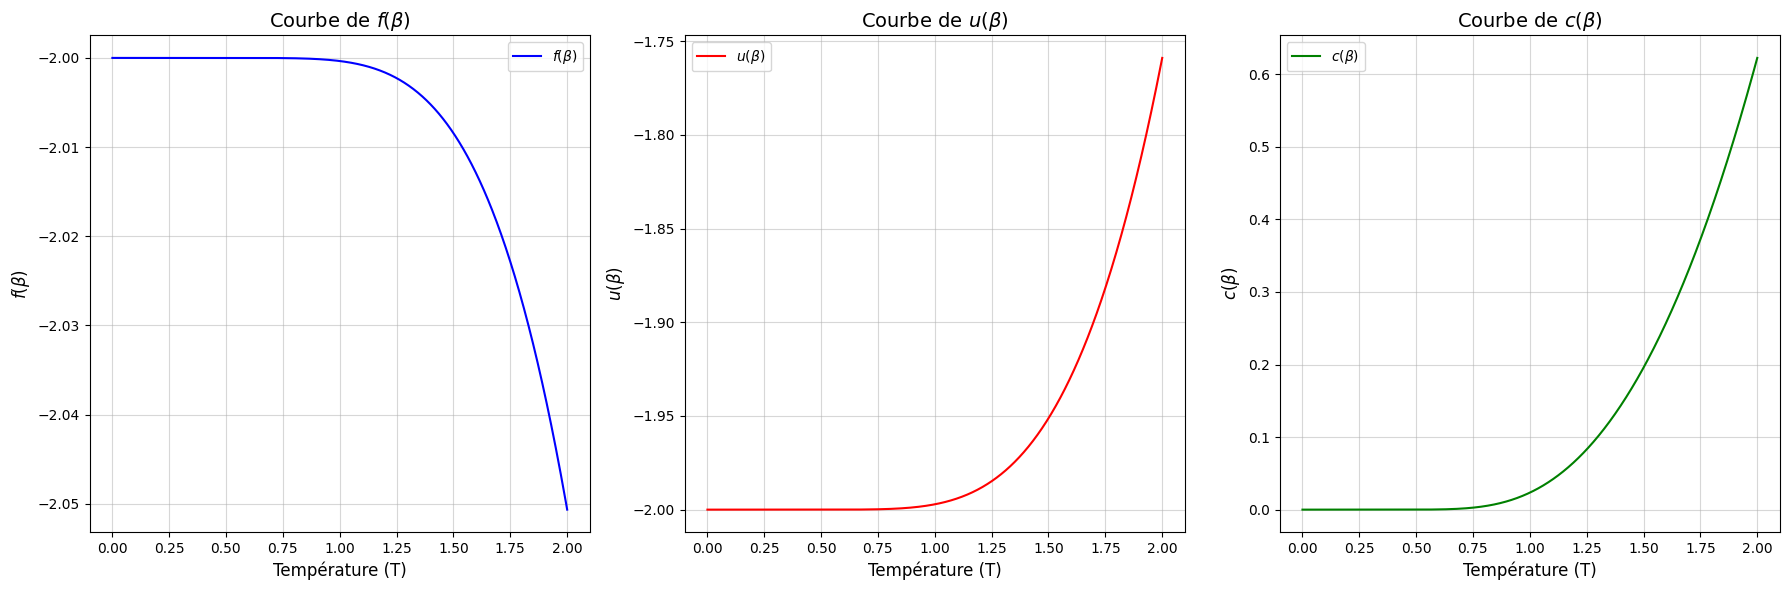

In [9]:
# Paramètres de la simulation
J = 1.0  # Constante d'interaction
N = 100  # Nombre de sites étudiés
temperature_values = np.linspace(0.001, 2, 1000)  # Températures évaluées (éviter T=0 pour éviter division par zéro)
beta_values = 1 / temperature_values  # β : inverse de la température

# Définitions des fonctions
def exp(beta, J):
    return np.exp(- 2 * beta * J)

def f(beta, J):
    return - 2 * J - 1/beta * (
        exp(beta, J)**4 
        + 2 * exp(beta, J)**6
        + 9/2 * exp(beta, J)**8
        + 12 * exp(beta, J)**10
    )

def u(beta, J):
    return -2 * J + J * (
        8 * exp(beta, J)**4 
        + 24 * exp(beta, J)**6
        + 72 * exp(beta, J)**8
        + 240 * exp(beta, J)**10
    )

def c(beta, J):
    return beta**2 * J**2 * (
        64 * exp(beta, J)**4 
        + 288 * exp(beta, J)**6
        + 1152 * exp(beta, J)**8
        + 4800 * exp(beta, J)**10
    )

# Calcul des valeurs pour f(β), u(β) et c(β)
f_values = f(beta_values, J)
u_values = u(beta_values, J)
c_values = c(beta_values, J)

# Création des sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Graphique 1 : f(β)
axes[0].plot(temperature_values, f_values, color='blue', label=r"$f(\beta)$")
axes[0].set_title("Courbe de $f(\\beta)$", fontsize=14)
axes[0].set_xlabel("Température (T)", fontsize=12)
axes[0].set_ylabel(r"$f(\beta)$", fontsize=12)
axes[0].grid(alpha=0.5)
axes[0].legend(fontsize=10)

# Graphique 2 : u(β)
axes[1].plot(temperature_values, u_values, color='red', label=r"$u(\beta)$")
axes[1].set_title("Courbe de $u(\\beta)$", fontsize=14)
axes[1].set_xlabel("Température (T)", fontsize=12)
axes[1].set_ylabel(r"$u(\beta)$", fontsize=12)
axes[1].grid(alpha=0.5)
axes[1].legend(fontsize=10)

# Graphique 3 : c(β)
axes[2].plot(temperature_values, c_values, color='green', label=r"$c(\beta)$")
axes[2].set_title("Courbe de $c(\\beta)$", fontsize=14)
axes[2].set_xlabel("Température (T)", fontsize=12)
axes[2].set_ylabel(r"$c(\beta)$", fontsize=12)
axes[2].grid(alpha=0.5)
axes[2].legend(fontsize=10)

# Ajustement de l'espacement entre les sous-graphiques
plt.tight_layout()

# Affichage
plt.show()

## Part III - Simulation Monte Carlo

In [10]:
# Functions 

def energy_variation_2d(s: np.ndarray, J: float, pos: tuple, verbosity: int = 0) -> float:
    i, j = pos  # Coordonnées du spin
    s_i = s[i, j]  # Spin à la position actuelle

    # Taille du réseau
    rows, cols = s.shape

    # Voisins avec gestion des bords (périodicité)
    voisins = s[i, (j - 1) % cols] + s[i, (j + 1) % cols] + s[(i - 1) % rows, j] + s[(i + 1) % rows, j]

    # Variation d'énergie (flip du spin)
    delta_energy = 2 * J * s_i * voisins

    # Affichage si verbosité > 1
    if verbosity > 1:
        print(f"Spin: ({i}, {j}) = {s_i}")
        print(f"Voisins: gauche={s[(i, (j - 1) % cols)]}, droite={s[(i, (j + 1) % cols)]}, haut={s[(i - 1) % rows, j]}, bas={s[(i + 1) % rows, j]}")
        print(f"Variation d'énergie: {delta_energy}")

    return delta_energy


# Algorithme de Metropolis 2D
def metropolis_simulation_2d(s_init: np.ndarray, J: float, beta: float, n_steps: int, verbosity: int = 0) -> np.ndarray:
    # Copie des spins pour éviter de modifier l'entrée
    spins = s_init.copy()
    rows, cols = spins.shape  # Dimensions du réseau de spins

    # Pré-calcul pour éviter de recalculer exp(-beta * delta_E) inutilement
    exp_lookup = {delta_E: np.exp(-beta * delta_E) for delta_E in range(-8, 9, 4)}

    for step in range(n_steps):
        # Choisir un spin aléatoirement
        i, j = np.random.randint(0, rows), np.random.randint(0, cols)
        
        # Calculer la variation d'énergie associée à un flip du spin
        delta_E = energy_variation_2d(spins, J, (i, j))
        
        # Accepter le flip si delta_E <= 0 ou avec une probabilité donnée par exp(-beta * delta_E)
        if delta_E <= 0 or np.random.rand() < exp_lookup.get(delta_E, 0):
            spins[i, j] *= -1

        # Afficher la progression à intervalles réguliers
        if verbosity > 0 and (step + 1) % max(1, n_steps // 10) == 0:
            print(f"Progression : {100 * (step + 1) // n_steps}%")

    # Affichage détaillé en fonction du niveau de verbosité
    if verbosity > 2:
        print(f"\nConfiguration initiale des spins :\n{s_init}")
        print(f"\nConfiguration finale des spins :\n{spins}")

    return spins


def energy_per_spin_2d(s: np.ndarray, J: float, verbosity: int = 0) -> float:
    rows, cols = s.shape

    # Définir les voisins : à droite et en bas avec gestion des bords (périodicité)
    s_droite = np.roll(s, shift=-1, axis=1)  # Voisin à droite (périodicité en colonne)
    s_bas = np.roll(s, shift=-1, axis=0)     # Voisin en bas (périodicité en ligne)
    
    # Calcul de l'énergie totale pour chaque spin
    energy_total = -J * np.sum(s * (s_droite + s_bas))

    # Calcul de l'énergie par spin
    energy_per_spin = energy_total / (rows * cols)

    # Affichage des résultats si verbosité est active
    if verbosity > 0:
        print(f"Énergie totale : {energy_total}")
        print(f"Énergie par spin : {energy_per_spin}")

    return energy_per_spin


def specific_heat_per_spin(T: float, J: float, spins: np.ndarray, verbosity: int = 0) -> float:
    beta = 1 / (T * J)

    # Calcul de l'énergie par spin
    E = energy_per_spin_2d(spins, J, verbosity)
    
    # Calcul de l'énergie au carré une seule fois
    E2 = energy_per_spin_2d(spins, J, verbosity)**2
    
    # Chaleur spécifique
    specific_heat = (E2 - E**2) * beta**2
    
    if verbosity > 0:
        print(f"Chaleur spécifique par spin : {specific_heat}")

    return specific_heat


Cmoputation : T = 2.0
Progression (T = 2.0): 1000/10000 (10%)
Progression (T = 2.0): 2000/10000 (20%)
Progression (T = 2.0): 3000/10000 (30%)
Progression (T = 2.0): 4000/10000 (40%)
Progression (T = 2.0): 5000/10000 (50%)
Progression (T = 2.0): 6000/10000 (60%)
Progression (T = 2.0): 7000/10000 (70%)
Progression (T = 2.0): 8000/10000 (80%)
Progression (T = 2.0): 9000/10000 (90%)
Progression (T = 2.0): 10000/10000 (100%)

Cmoputation : T = 2.6
Progression (T = 2.6): 1000/10000 (10%)
Progression (T = 2.6): 2000/10000 (20%)
Progression (T = 2.6): 3000/10000 (30%)
Progression (T = 2.6): 4000/10000 (40%)
Progression (T = 2.6): 5000/10000 (50%)
Progression (T = 2.6): 6000/10000 (60%)
Progression (T = 2.6): 7000/10000 (70%)
Progression (T = 2.6): 8000/10000 (80%)
Progression (T = 2.6): 9000/10000 (90%)
Progression (T = 2.6): 10000/10000 (100%)

Cmoputation : T = 3.0
Progression (T = 3.0): 1000/10000 (10%)
Progression (T = 3.0): 2000/10000 (20%)
Progression (T = 3.0): 3000/10000 (30%)
Progres

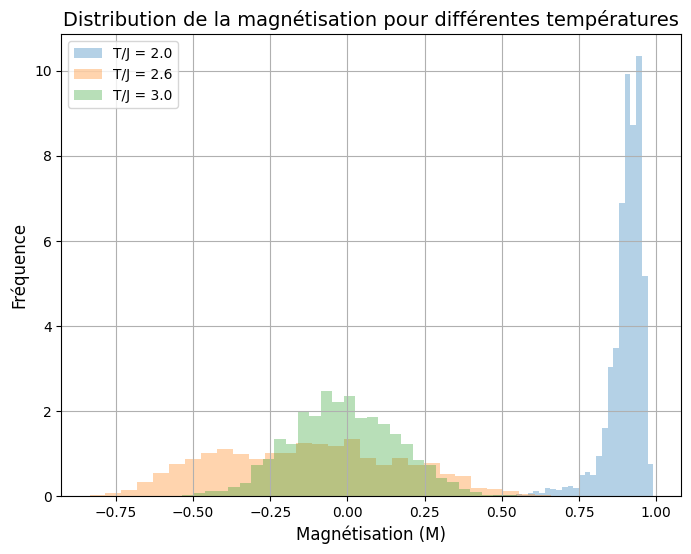

In [11]:
# Paramètres de la simulation
J = 1.0  # Constante d'interaction
N = 20  # Taille du système (NxN)
verbosity = 2 # verbosité de la simulation 
n_steps = int(1e4) # Nombre d'iteration avant la thermalisation
s_init = np.random.choice([-1, 1], size=(N, N))  # Initialisation aléatoire des spins
temperatures_values = [2.0, 2.6, 3.0] # Températures pour lesquelles on veut observer la distribution
n_runs = int(1e4) # nombre de simulation sur lesquelles ont moyenne
n_delta = int(1e2) # ecart entre chaque evalutation des metriques

if verbosity > 2:
    print(f"\nDonnées d'initialisation de la simulation : \n")
    print(f"J : {J}")
    print(f"N : {N}")
    print(f"nombre de step pour atteindre la thermalisation : {n_steps}")
    print(f"nombre d'iterations pour calculer la moyenne : {n_runs}")
    print(f"Températures étudiées : {temperatures_values}")
    print(f"système initial de spins de la simulation : \n{s_init}\n")

plt.figure(figsize=(8, 6))

for T in temperatures_values:
    beta = 1 / (T * J)
    magnetizations = []
    spins = metropolis_simulation_2d(s_init.copy(), J, beta, n_steps, verbosity=0)
    if  verbosity > 0 :
        print(f"\nCmoputation : T = {T}")

    # Effectuer plusieurs simulations pour chaque température
    for step in range(n_runs):
        spins = metropolis_simulation_2d(spins, J, beta, n_delta, verbosity=0)
        magnetizations.append(np.sum(spins) / spins.size)  # Calculer la magnétisation après thermalisation
        if verbosity > 1 and (step + 1) % (n_runs // 10) == 0:
            print(f"Progression (T = {T}): {step+1}/{n_runs} ({100 * (step + 1) // n_runs}%)")
    
    # Tracer l'histogramme de la magnétisation
    plt.hist(magnetizations, bins=30, alpha=1/len(temperatures_values), label=f'T/J = {T/J:.1f}', density=True)

plt.xlabel('Magnétisation (M)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend()
plt.title("Distribution de la magnétisation pour différentes températures", fontsize=14)
plt.grid(True)
plt.show()

On observe que à une température de 2.0, la distribution est concentrée soit en -1 ou en 1. Puis plus la température augmente, plus la distribution se concentre en 0. Cela s'explique que pour un modèle d'Ising en 2 dimension, la transition de phase se situe $ T_{trans}\approx$ 2.3. Donc on observe bien que en dessous de cette température les spins tendent à s'aligner grâce aux liaisons dû à l'hamiltonien. Et au dessus, les fluctuations thermiques prennent le dessus et désordonnent les spins ce qui donne une moyenne de magnétisation à 0.

## Part IV — Solution Exacte et Comparaison avec les Expansions

On note $\beta f(\beta)$ avec $f(\beta)$ l'énergie libre par site : 
\begin{equation}
-\beta f(\beta) = \ln(2 \cosh(2 \beta J)) + \frac{1}{\pi} \int_0^{\pi/2} d\theta \ln \, \left[ \frac{1}{2} \left( 1 + \sqrt{1- \left(\frac{2\sinh (2 \beta J)}{\cosh^2 (2 \beta J)}\right)^2 \sin^2 \theta } \right)  \right]
\end{equation}

On pose :

\begin{equation}
    K = \frac{2 \sinh (2 \beta J)}{\cosh^2 (2 \beta J)}\ \ \  et  \ \ \ \Delta  = \sqrt{1 - K^2 \sin^2 \theta}
\end{equation}
On a : 

\begin{equation}
    \frac{\partial K}{\partial \beta} = \frac{4 J \cosh^2 (2 \beta J) - 8 J \sinh^2 (2 \beta J)}{\cosh^3 (2 \beta J)}
\end{equation}

donc

\begin{equation}
- e(\beta) = \frac{\partial (-\beta f(\beta))}{\partial \beta} = 2J \tanh (2 \beta J) -  \frac{\partial K}{\partial \beta} \frac{ K}{\pi}  \int_0^{\pi/2} d\theta \, \frac{\sin^2 \theta}{\Delta (\Delta + 1)} =2J \tanh (2 \beta J) -  \frac{\partial K}{\partial \beta} \frac{ K}{2\pi}  \int_0^{\pi} d\theta \, \frac{\sin^2 \theta}{\Delta (\Delta + 1)}
\end{equation}

Où l'on a utilisé la propriété du roi dans la dernière égalité.

\begin{equation}

\end{equation}


De plus,

\begin{equation}
      1 - \Delta ^2 = 1 - (1 - K^2 \sin^2(\theta)) = K^2 \sin^2(\theta) \Rightarrow \sin^2(\theta) = \frac{1 - \Delta ^2}{K^2} = \frac{(1 - \Delta)(1+\Delta)}{K^2} 
\end{equation}

On peut donc utiliser la propriété suivante : 
\begin{equation}
    \int_0^\pi d\theta \, \frac{\sin^2 \theta}{\Delta (\Delta + 1)} = \frac{-\pi}{K^2} + \frac{1}{K ^2} \int ^{\pi} _{0} \frac{d \theta}{\Delta}
\end{equation}



L'équation devient donc : 

\begin{equation}
     e(\beta) = - 2J \tanh (2 \beta J) +  \frac{\partial K}{\partial \beta} \frac{ K}{2\pi}  \int_0^\pi d\theta \, \frac{\sin^2 \theta}{\Delta (\Delta + 1)} = - 2J \tanh (2 \beta J) + \frac{\partial K}{\partial \beta} \frac{1}{2K} \left( -1 + 2\int_0^{\pi/2} d\theta   \frac{1}{\pi} \frac{1}{\Delta} \right) 
\end{equation} 


Finalement on calcule $\frac{\partial K}{\partial \beta} \frac{1}{K}$ : 
\begin{equation}
    \frac{\partial K}{\partial \beta} \frac{1}{K} = 2J \coth(2 \beta J)(1 - 2 \tanh^2(2 \beta J))
\end{equation}


Or
\begin{equation}
    2 \tanh(x) + \coth(x)(1-2\tanh^2(x)) = \coth(x)
\end{equation}

On remplace et on trouve bien la relation :
$$
e(\beta) = -J \coth(2\beta J) \left[ 1 + \frac{2}{\pi} \left( 2\tanh^2(2\beta J) - 1 \right) \int_0^{\pi/2} \frac{1}{\sqrt{1 - \frac{2\sinh^2(2\beta J)}{\cosh^2(2\beta J)} \sin^2(\phi)}} d\phi \right]
$$




L'énergie moyenne par site est donnée par :
$$
e(\beta) = -J \coth(2\beta J) \left[ 1 + \frac{2}{\pi} \left( 2\tanh^2(2\beta J) - 1 \right) \int_0^{\pi/2} \frac{1}{\sqrt{1 - \frac{2\sinh^2(2\beta J)}{\cosh^2(2\beta J)} \sin^2(\phi)}} d\phi \right]
$$

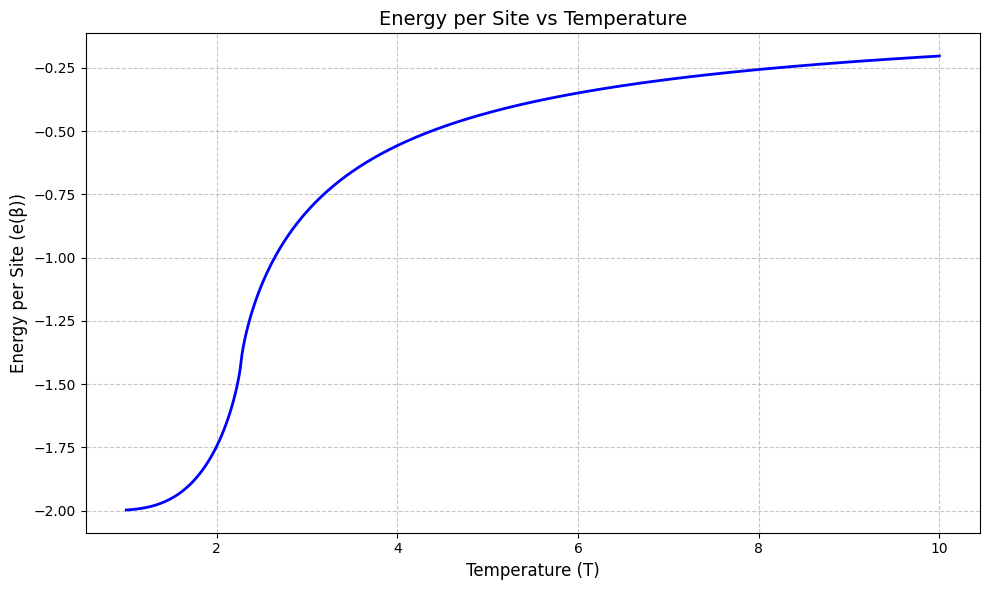

In [12]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

def energy_per_site(beta, J):
    # Compute intermediate hyperbolic functions
    coth_term = np.cosh(2 * beta * J) / np.sinh(2 * beta * J)
    
    # Define the integrand with numerical stability improvements
    def integrand(phi):
        # Avoid numerical instability by checking the denominator
        term = (2 * np.sinh(2 * beta * J) / np.cosh(2 * beta * J)**2)**2 * np.sin(phi)**2
        if np.isclose(term, 1.0, rtol=1e-10):
            return 0.0  # Handle the singularity case
        return np.real(1.0 / np.sqrt(1 - term))
    
    try:
        # Perform numerical integration with error handling
        integral_result, error = quad(integrand, 0, np.pi/2)
        
        # Compute the full energy expression
        energy = -J * coth_term * (1 + (2/np.pi) * (2 * np.tanh(2 * beta * J)**2 - 1) * integral_result)
        return energy
    except (ValueError, RuntimeWarning) as e:
        print(f"Error at beta={beta}: {e}")
        return np.nan

def plot_energy_vs_temperature(beta_range, J):
    # Compute temperatures and corresponding energies
    temperatures = [1 / (beta / J) for beta in beta_range]
    energies = [energy_per_site(beta, J) for beta in beta_range]
    
    # Remove any NaN values before plotting
    valid_points = [(t, e) for t, e in zip(temperatures, energies) if not np.isnan(e)]
    if valid_points:
        temperatures, energies = zip(*valid_points)
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(temperatures, energies, 'b-', linewidth=2)
    plt.title('Energy per Site vs Temperature', fontsize=14)
    plt.xlabel('Temperature (T)', fontsize=12)
    plt.ylabel('Energy per Site (e(β))', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add some styling
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    return energies

# Paramètres de simulation
J = 1.0
temperatures_values = np.linspace(1, 10, 1000)  # Températures pour lesquelles on veut observer la distribution
betas = [1 / (T / J) for T in temperatures_values]  # Inverse de la température (1/T)

# Exécution du calcul et tracé
energies = plot_energy_vs_temperature(betas, J)

## Q2 

### a. 
Nous allons maintenant comparer quatre approches différentes pour calculer l’énergie du système : la
simulation Monte Carlo, la solution exacte d’Onsager, le développement à haute température et le
développement à basse température.

In [13]:
# Paramètres de la simulation CODE DU MAIL

# Paramètres de la simulation

J = 1.0 # Constante d'interaction
N = 128 # Taille du système (NxN)
verbosity = 2 # verbosité de la simulation 
n_steps = int(1e4) # Nombre d'iteration avant la thermalisation
n_runs = int(1e4) # nombre de simulation sur lesquelles ont moyenne
nbr_it = int(1e2) # Nombre d'itérations pour les mesures
temperatures_values = np.linspace(0.001, 30, 30) # Températures pour lesquelles on veut observer la distribution
betas = [1 / (T / J) for T in temperatures_values] # Inverse de la température (1/T)


if verbosity > 2:

    print(f"\nDonnées d'initialisation de la simulation : \n")
    print(f"J : {J}")
    print(f"N : {N}")
    print(f"nombre de step pour atteindre la thermalisation : {n_steps}")
    print(f"nombre d'iterations pour calculer la moyenne : {n_runs}")
    print(f"Températures étudiées : {temperatures_values}")
    print(f"système initial de spins de la simulation : \n{s_init}\n")


# Plot the energy vs temperature
energies_Onsager = [energy_per_site(beta, J) for beta in betas]


# Optional: print some specific values

if verbosity > 2:
    print("Energy at specific temperatures:")
    test_temps = [0.5, 1.0, 2.0, 4.0]

    for T in test_temps:
        beta = 1 / T
        e = energy_per_site(beta, 1.0)
        print(f"T = {T:.2f}, e(β) = {e:.6f}")


# Préparer les tableaux pour les résultats
E_means_avg = np.zeros(len(temperatures_values))


# Fonction principale
for idx, (T, beta) in enumerate(zip(temperatures_values, betas)):

    if verbosity > 0:
        print(f"Simulation pour T/J = {T:.2f}...")

    # Initialiser les accumulateurs pour ⟨E⟩ et ⟨E²⟩
    energy_accum = 0.0

    # Initialisation aléatoire des spins
    s_init = np.ones((N, N), dtype=int)

    # Étape de thermalisation
    s_thermalized = metropolis_simulation_2d(s_init, J, beta, n_steps, verbosity=0)

    for it in range(n_runs):

        s_thermalized = metropolis_simulation_2d(s_thermalized, J, beta, nbr_it, verbosity=0)
        energy_accum += energy_per_spin_2d(s_thermalized, J, verbosity=0)

        # Progression
        if verbosity > 1 and (it + 1) % (n_runs // 10) == 0:
            print(f"Progression : {100 * (it + 1) // n_runs}%")

    # Calcul des moyennes ⟨E⟩ et ⟨E²⟩ pour cette température
    E_mean = energy_accum / n_runs

    # Stocker les résultats
    E_means_avg[idx] = E_mean

    if verbosity > 0:
        print(f"T/J = {T:.2f}: ⟨E⟩ = {E_mean:.4f}")

/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_47179/4196866508.py:7: RuntimeWarning: overflow encountered in cosh
  coth_term = np.cosh(2 * beta * J) / np.sinh(2 * beta * J)
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_47179/4196866508.py:7: RuntimeWarning: overflow encountered in sinh
  coth_term = np.cosh(2 * beta * J) / np.sinh(2 * beta * J)
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_47179/4196866508.py:7: RuntimeWarning: invalid value encountered in scalar divide
  coth_term = np.cosh(2 * beta * J) / np.sinh(2 * beta * J)
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_47179/4196866508.py:12: RuntimeWarning: overflow encountered in sinh
  term = (2 * np.sinh(2 * beta * J) / np.cosh(2 * beta * J)**2)**2 * np.sin(phi)**2
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_47179/4196866508.py:12: RuntimeWarning: overflow encountered in cosh
  term = (2 * np.sinh(2 * beta * J) / np.cosh(2 * beta * J)**2)**2 * np.sin(phi)**2
/

Simulation pour T/J = 0.00...
Progression : 10%
Progression : 20%
Progression : 30%
Progression : 40%
Progression : 50%
Progression : 60%
Progression : 70%
Progression : 80%
Progression : 90%
Progression : 100%
T/J = 0.00: ⟨E⟩ = -2.0000
Simulation pour T/J = 1.04...
Progression : 10%
Progression : 20%
Progression : 30%
Progression : 40%
Progression : 50%
Progression : 60%
Progression : 70%
Progression : 80%
Progression : 90%
Progression : 100%
T/J = 1.04: ⟨E⟩ = -1.9967
Simulation pour T/J = 2.07...
Progression : 10%
Progression : 20%
Progression : 30%
Progression : 40%
Progression : 50%
Progression : 60%
Progression : 70%
Progression : 80%
Progression : 90%
Progression : 100%
T/J = 2.07: ⟨E⟩ = -1.7023
Simulation pour T/J = 3.10...
Progression : 10%
Progression : 20%
Progression : 30%
Progression : 40%
Progression : 50%
Progression : 60%
Progression : 70%
Progression : 80%
Progression : 90%
Progression : 100%
T/J = 3.10: ⟨E⟩ = -0.8227
Simulation pour T/J = 4.14...
Progression : 10%
Prog

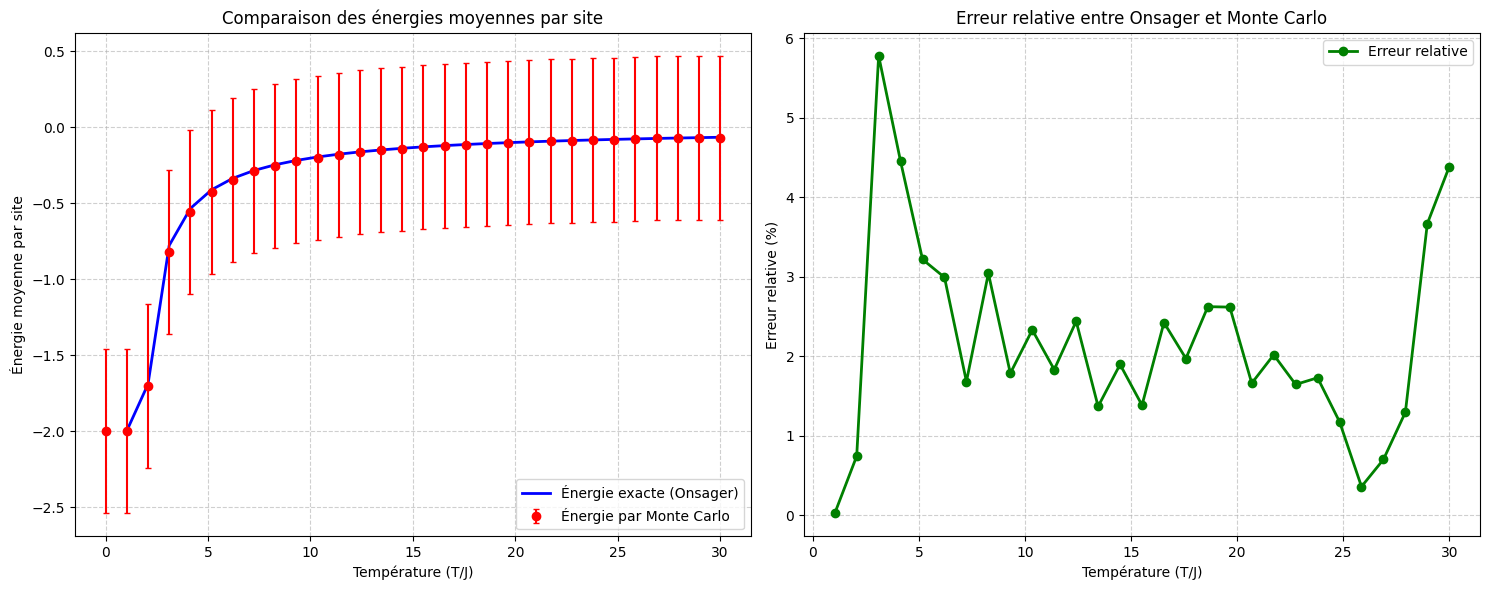

In [14]:
# Calcul de l'erreur relative  CODE MAIL

def calculate_relative_error(exact, approximation):
    return np.abs((exact - approximation) / exact) * 100


# Calcul de l'erreur relative entre les énergies Onsager et Monte Carlo
relative_errors = calculate_relative_error(energies_Onsager, E_means_avg)
E_means_std = np.std(E_means_avg)

np.logspace(-1, np.log10(50), 50)


# Création de la figure avec deux sous-graphiques
plt.figure(figsize=(15, 6))


# Premier sous-graphique : Énergies originales
plt.subplot(1, 2, 1)
plt.plot(temperatures_values, energies_Onsager, label="Énergie exacte (Onsager)", color="blue", linewidth=2)
plt.errorbar(temperatures_values, E_means_avg, yerr=E_means_std ,fmt='o', label="Énergie par Monte Carlo", color="red", capsize=2)
plt.title("Comparaison des énergies moyennes par site", fontsize=12)
plt.xlabel("Température (T/J)", fontsize=10)
plt.ylabel("Énergie moyenne par site", fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)


# Deuxième sous-graphique : Erreur relative
plt.subplot(1, 2, 2)
plt.plot(temperatures_values, relative_errors, label="Erreur relative", color="green", linewidth=2, marker='o')
plt.title("Erreur relative entre Onsager et Monte Carlo", fontsize=12)
plt.xlabel("Température (T/J)", fontsize=10)
plt.ylabel("Erreur relative (%)", fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)


# Ajustement de la mise en page
plt.tight_layout()


# Affichage du graphique
plt.show()

Statistiques de l'erreur relative :
Erreur moyenne : 2.1800%
Erreur maximale : 5.7827%
Erreur minimale : 0.0210%
Écart-type de l'erreur : 1.2459%


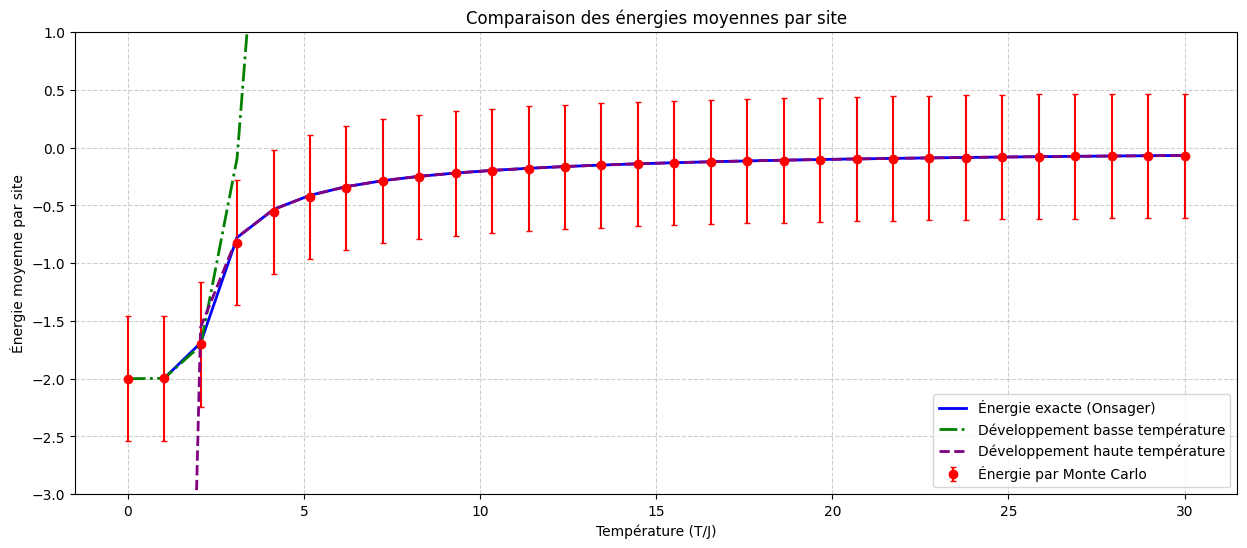

In [15]:
# Filtrage des NaN pour les statistiques CODE MAIL
valid_errors = relative_errors[~np.isnan(relative_errors)]


# Impression des statistiques d'erreur
print("Statistiques de l'erreur relative :")
print(f"Erreur moyenne : {np.mean(valid_errors):.4f}%")
print(f"Erreur maximale : {np.max(valid_errors):.4f}%")
print(f"Erreur minimale : {np.min(valid_errors):.4f}%")
print(f"Écart-type de l'erreur : {np.std(valid_errors):.4f}%")





def u_basse(beta, J, order):

    if order == 4:
        return - 2 * J + J * (8 * np.exp(-2 * beta * J)**4)

    elif order == 6:
        return - 2 * J + J * (8 * np.exp(-2 * beta * J)**4 + 24 * np.exp(-2 * beta * J)**6)

    elif order == 8:
        return - 2 * J + J * (8 * np.exp(-2 * beta * J)**4 + 24 * np.exp(-2 * beta * J)**6 + 72 * np.exp(-2 * beta * J)**8)

    elif order == 10:
        return - 2 * J + J * (8 * np.exp(-2 * beta * J)**4 + 24 * np.exp(-2 * beta * J)**6 + 72 * np.exp(-2 * beta * J)**8 + 240 * np.exp(-2 * beta * J)**10)
    
    else:
        raise ValueError("Order must be 4, 6, 8, or 10")



def kappa(beta, J):
    return np.tanh(beta * J)



def u_haute(beta, J):

    terms = [kappa(beta, J)] 
    terms.append(2 * kappa(beta, J)**3)
    terms.append(4 * kappa(beta, J)**5)
    terms.append(12 * kappa(beta, J)**7)
    terms.append(42 * kappa(beta, J)**9)

    return -2 * J * sum(terms)





# Création de la figure avec deux sous-graphiques

plt.figure(figsize=(15, 6))

plt.plot(temperatures_values, energies_Onsager, label="Énergie exacte (Onsager)", color="blue", linewidth=2, linestyle='-')
plt.errorbar(temperatures_values, E_means_avg, yerr=E_means_std ,fmt='o', label="Énergie par Monte Carlo", color="red", capsize=2)
plt.plot(temperatures_values, [u_basse(beta, J, 10) for beta in betas], label=f"Développement basse température", color='green',linewidth=2, linestyle='-.')
plt.plot(temperatures_values, [u_haute(beta, J) for beta in betas], label=f"Développement haute température", color='purple',linewidth=2, linestyle='--')
plt.title("Comparaison des énergies moyennes par site", fontsize=12)
plt.xlabel("Température (T/J)", fontsize=10)
plt.ylabel("Énergie moyenne par site", fontsize=10)
plt.legend(fontsize=10)
plt.ylim((-3, 1))
plt.grid(True, linestyle="--", alpha=0.6)





# Affichage du graphique
plt.show()


### b.
On ajoute sur le graphique les développements à haute et basse températures

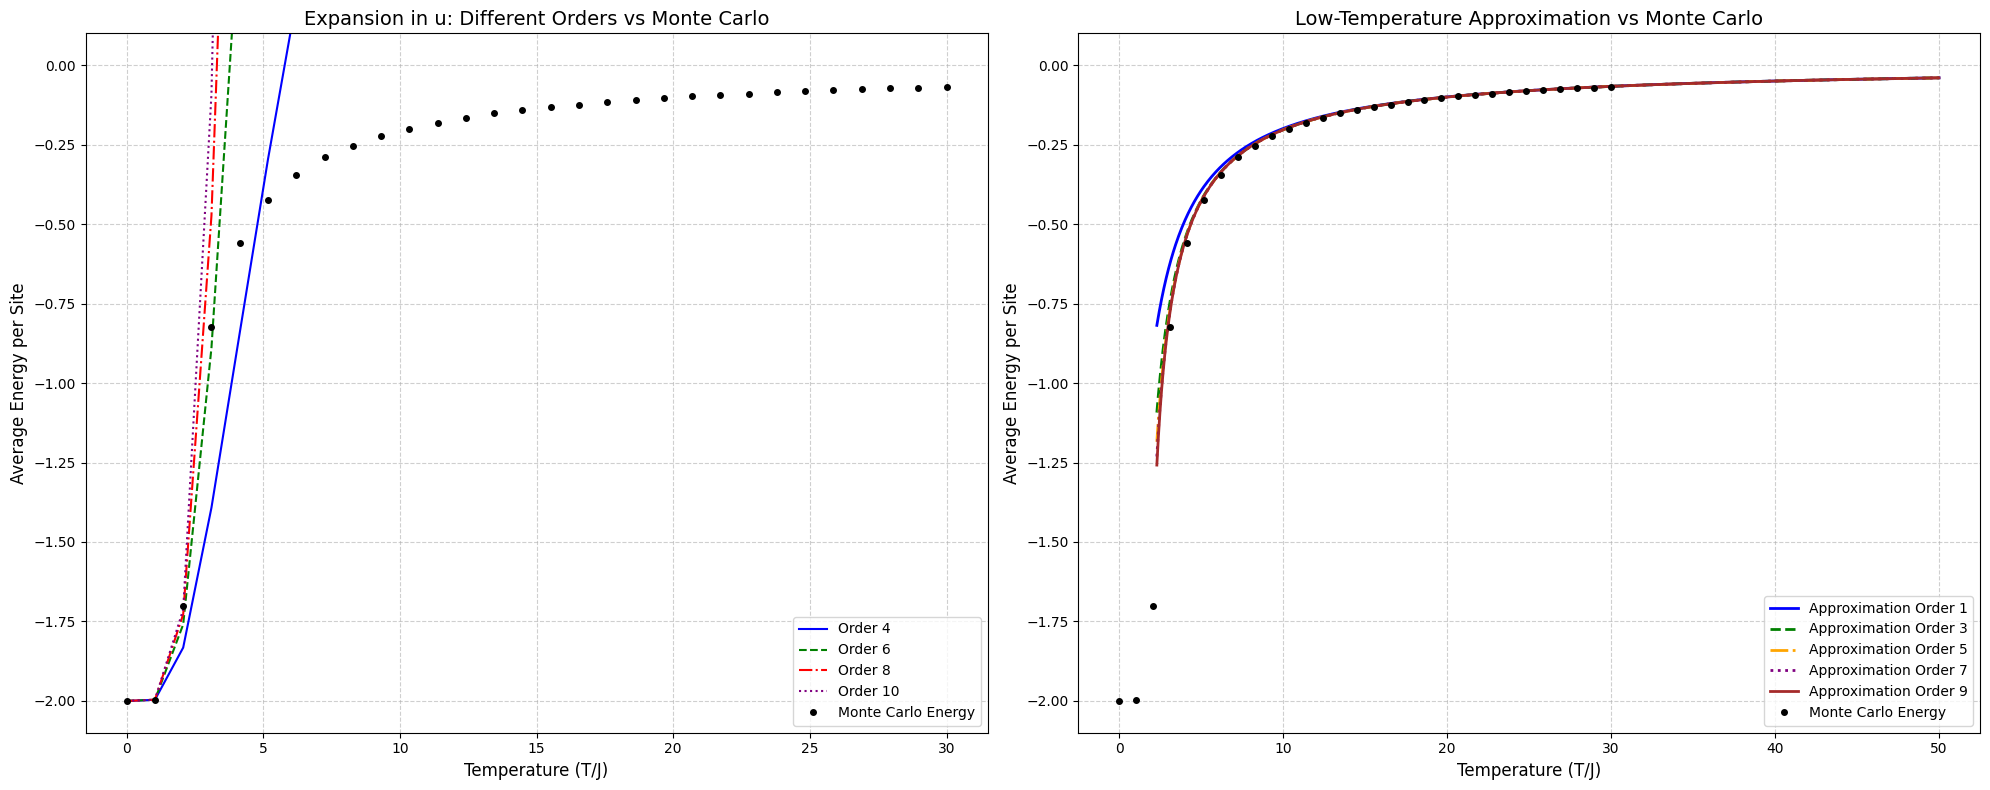

In [16]:
def u_approx(beta, J, order): #CODE MAIL
    terms = [kappa(beta, J)] # Start with the first term
    if order >= 3:
        terms.append(2 * kappa(beta, J)**3)
    if order >= 5:
        terms.append(4 * kappa(beta, J)**5)
    if order >= 7:
        terms.append(12 * kappa(beta, J)**7)
    if order >= 9:
        terms.append(42 * kappa(beta, J)**9)
    return -2 * J * sum(terms)



def u(beta, J, order):
    if order == 4:
        return - 2 * J + J * (8 * np.exp(-2 * beta * J)**4)
    elif order == 6:
      return - 2 * J + J * (8 * np.exp(-2 * beta * J)**4 + 24 * np.exp(-2 * beta * J)**6)
    elif order == 8:
       return - 2 * J + J * (8 * np.exp(-2 * beta * J)**4 + 24 * np.exp(-2 * beta * J)**6 + 72 * np.exp(-2 * beta * J)**8)
    elif order == 10:
      return - 2 * J + J * (8 * np.exp(-2 * beta * J)**4 + 24 * np.exp(-2 * beta * J)**6 + 72 * np.exp(-2 * beta * J)**8 + 240 * np.exp(-2 * beta * J)**10)
    else:
      raise ValueError("Order must be 4, 6, 8, or 10")


# Création de la figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Premier sous-graphique (expansion en u)
orders = [4, 6, 8, 10]
colors = ['blue', 'green', 'red', 'purple']
linestyles = ['-', '--', '-.', ':']



for order, color, ls in zip(orders, colors, linestyles):
    ax1.plot(temperatures_values,[u(beta, J, order) for beta in betas],label=f"Order {order}",color=color,linestyle=ls)


# Ajout des points Monte Carlo

ax1.plot(temperatures_values, E_means_avg,label="Monte Carlo Energy",color="black",marker='o',linestyle='None',markersize=4)


# Formatage du premier sous-graphique

ax1.set_title("Expansion in u: Different Orders vs Monte Carlo", fontsize=14)
ax1.set_ylim((-2.1, 0.1))
ax1.set_xlabel("Temperature (T/J)", fontsize=12)
ax1.set_ylabel("Average Energy per Site", fontsize=12)
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(True, linestyle="--", alpha=0.6)



# Deuxième sous-graphique (approximation basse température)
orders = [1, 3, 5, 7, 9]
colors = ['blue', 'green', 'orange', 'purple', 'brown']
linestyles = ['-', '--', '-.', ':', '-']



temperatures_values_form = np.linspace(2.3, 50, 1000)
betas_form = [1 / (T / J) for T in temperatures_values_form]



for i, order in enumerate(orders):

    f_values = [u_approx(beta, J, order) for beta in betas_form]
    ax2.plot(temperatures_values_form, f_values,label=f"Approximation Order {order}",color=colors[i],linewidth=2,linestyle=linestyles[i])


# Ajout des points Monte Carlo

ax2.plot(temperatures_values, E_means_avg, 'o',label="Monte Carlo Energy",color="black",markersize=4)


# Formatage du deuxième sous-graphique
ax2.set_title("Low-Temperature Approximation vs Monte Carlo", fontsize=14)
ax2.set_xlabel("Temperature (T/J)", fontsize=12)
ax2.set_ylabel("Average Energy per Site", fontsize=12)
ax2.legend(fontsize=10, loc='lower right')
ax2.set_ylim((-2.1, 0.1))
ax2.grid(True, linestyle="--", alpha=0.6)


# Ajustement de la mise en page
plt.tight_layout()

# Affichage de la figure
plt.show()

### c.

Les simulations de Monte Carlo reproduisent avec précision la dynamique de la solution exacte. En particulier, on constate que l’erreur relative reste inférieure à $7 %$ , avec une erreur relative moyenne inférieure à $3 %$.



L’approximation à basse température permet de bien décrire le comportement de l’énergie moyenne en dessous de la température critique $T_c$. Il est également observé qu’une augmentation de l’ordre de l’approximation améliore significativement l’ajustement des résultats.



De même, l’approximation à haute température permet de décrire correctement le comportement de l’énergie interne moyenne pour des températures supérieures à $7$ K. L’augmentation de l’ordre de l’approximation améliore également la précision des résultats. Dès le cinquième ordre, l’approximation converge suffisamment près de la solution exacte et des simulations de Monte Carlo.




## Part V —Le Cumulant de Binder

Le cumulant de Binder (ou plus précisément, la kurtosis) s'exprime de la manière suivante :  
$$U_N = 1 - \frac{\langle m^4 \rangle_N}{3 \langle m^2 \rangle_N^2}$$
où :
- $m = \frac{1}{N^2}\sum_{i,j=1}^N s_{i,j}$ représente l'aimantation moyenne par site,
- $\langle \cdot \rangle_N$ désigne la moyenne thermodynamique pour un système de taille linéaire $N$.

### Moments de la distribution
Les moments $\langle m^n \rangle_N$ peuvent être exprimés en termes des paramètres de la distribution ($\mu$ : moyenne, $\sigma^2$ : variance) comme suit :
- Moment d'ordre 1 :  
  $$\langle m^1 \rangle = \mu$$
- Moment d'ordre 2 :  
  $$\langle m^2 \rangle = \sigma^2 + \mu^2$$
- Moment d'ordre 3 :  
  $$\langle m^3 \rangle = 3 \mu \sigma^2 + \mu^3$$
- Moment d'ordre 4 :  
  $$\langle m^4 \rangle = 3 \sigma^4 + 6 \sigma^2 \mu^2 + \mu^4$$

## Q1 

Pour $T > T_c$ (phase paramagnétique), la distribution de l’aimantation devient gaussienne dans la limite thermodynamique. Dans ce cas particulier, pour une distribution normale centrée ($\mu = 0$), les moments pertinents s'écrivent :
$$\langle m^2 \rangle = \sigma^2, \quad \langle m^4 \rangle = 3 \sigma^4$$
En substituant ces expressions dans la définition du cumulant de Binder, on obtient :
$$U_N = 1 - \frac{\langle m^4 \rangle_N}{3 \langle m^2 \rangle_N^2}$$
En remplaçant $\langle m^2 \rangle = \sigma^2$ et $\langle m^4 \rangle = 3 \sigma^4$, cela devient :
$$U_N = 1 - \frac{3 \sigma^4}{3 (\sigma^2)^2}$$
Simplifions :
$$U_N = 1 - \frac{3 \sigma^4}{3 \sigma^4} = 1 - 1 = 0$$
Dans la phase paramagnétique (\(T > T_c\)), où la distribution de l'aimantation est gaussienne, le cumulant de Binder \(U_N\) est nul :
$$U_N = 0$$
Cela confirme la symétrie et la nature gaussienne de la distribution dans cette phase.


## Q2

Pour $T < T_c$ (phase ferromagnétique), la distribution de l’aimantation tend vers deux pics de Dirac situés en $\pm m_*(T)$, où $(m_*(T)$ représente l’aimantation spontanée.

Dans ce cas, la distribution de $m$ est bimodale et symétrique. Cela implique que les moments thermodynamiques s'expriment comme suit :
1. **Moment d'ordre 1 (moyenne) :**
   $$\langle m \rangle = 0$$
   en raison de la symétrie de la distribution autour de zéro ($+m_*(T)$ et $-m_*(T)$).

2. **Moment d'ordre 2 :**
   $$\langle m^2 \rangle = m_*^2(T)$$
   car la contribution provient uniquement des deux pics.

3. **Moment d'ordre 4 :**
   $$\langle m^4 \rangle = m_*^4(T)$$
   pour la même raison (les pics contribuent uniquement à $\pm m_*(T)$).


En remplaçant ces moments dans l'expression de $U_N$ :
$$U_N = 1 - \frac{\langle m^4 \rangle}{3 \langle m^2 \rangle^2}$$
Substituons $\langle m^2 \rangle = m_*^2(T)$ et $\langle m^4 \rangle = m_*^4(T)$ :
$$U_N = 1 - \frac{m_*^4(T)}{3 \big(m_*^2(T)\big)^2}$$
Simplifions :
$$U_N = 1 - \frac{m_*^4(T)}{3 m_*^4(T)} = 1 - \frac{1}{3} = \frac{2}{3}$$


Dans la phase ferromagnétique ($T < T_c$), où la distribution de l'aimantation tend vers deux pics de Dirac en $\pm m_*(T)$, le cumulant de Binder prend la valeur :
$$U_N = \frac{2}{3}$$
Cela reflète la nature bimodale de la distribution, caractéristique de la phase ferromagnétique.

## Q3

In [17]:
def aimantation(s: np.ndarray, verbosity: int = 0):
    m = np.sum(s) / s.size  # Aimantation totale divisée par le nombre de sites
    if verbosity > 2:
        print(f"Aimantation (N = {s.size}) : m = {m}")
    return m

def cum_Binder(m_values: list, verbosity:int = 0) :

    # Convertir les données en numpy array pour simplifier les calculs
    m_values = np.array(m_values)

    # Calcul des moments d'ordre 2 et 4
    m2 = np.mean(np.square(m_values))  # ⟨m²⟩
    m4 = np.mean(np.power(m_values, 4))  # ⟨m⁴⟩

    # Calcul du cumulant de Binder
    U_N = 1 - m4 / (3 * m2**2)

    if verbosity > 1:
        print(f"Binder cumulant (moyenne sur {len(m_values)}): U_N = {U_N}")
    
    return U_N

## Q4

In [19]:
# Paramètres de la simulation 
N = [8, 16, 32, 64]  # Tailles de réseau
temperatures = [2.0, 2.1, 2.2, 2.3, 2.4, 2.5]  # Températures réduites T/J
beta_values = [1 / (T / J) for T in temperatures] # inverse de la temperature
J = 1.0  # Constante d'échange
n_runs = int(1e4) # nombre d'iteration pour faire la moyenne
n_steps = int(1e4) # nombre d'iteration pour atteindre la thermalisation
n_delta = int(1e2) # ecart entre chaque évalutation des metriques
m = {n: {T: [] for T in temperatures} for n in N} # Initialisation des listes pour stocker les résultats]
temp = 0

for n  in N :
    s_init = np.random.choice([-1, 1], size=(n, n)) # tableau de spins initiaux  de taille NxN
    for beta in beta_values :
        s = metropolis_simulation_2d(s_init, J, beta, n_steps, verbosity = 0) 
        for it in range(n_runs):
            s = metropolis_simulation_2d(s, J, beta, n_delta, verbosity = 0)
            m_temp = aimantation(s, verbosity = 0)
            m[n][1/beta].append(m_temp)

            if verbosity > 2:
                print(f"N = {n}, T = {1/beta}, aimantation = {m_temp:.4f}")

    if verbosity > 1 : 
        if verbosity > 2 : 
            print("\n")
        print(f"Progression : {100 * (temp + 1) / len(N):.2f}%")
        temp += 1

Progression : 25.00%
Progression : 50.00%


Binder cumulant (moyenne sur 10000): U_N = 0.6554927339328741
Binder cumulant (moyenne sur 10000): U_N = 0.6461667962377668
Binder cumulant (moyenne sur 10000): U_N = 0.628663441526907
Binder cumulant (moyenne sur 10000): U_N = 0.6074734456664004
Binder cumulant (moyenne sur 10000): U_N = 0.5737166712490591
Binder cumulant (moyenne sur 10000): U_N = 0.5256501144202672
Binder cumulant (moyenne sur 10000): U_N = 0.6555026273497142
Binder cumulant (moyenne sur 10000): U_N = 0.6584243345390915
Binder cumulant (moyenne sur 10000): U_N = 0.6319113883694113
Binder cumulant (moyenne sur 10000): U_N = 0.6089907104028894
Binder cumulant (moyenne sur 10000): U_N = 0.5157331085887072
Binder cumulant (moyenne sur 10000): U_N = 0.37252086008029617
Binder cumulant (moyenne sur 10000): U_N = 0.6537627426530885
Binder cumulant (moyenne sur 10000): U_N = 0.49609903701125213
Binder cumulant (moyenne sur 10000): U_N = 0.6354953629461342
Binder cumulant (moyenne sur 10000): U_N = 0.4017187566745547
Binder 

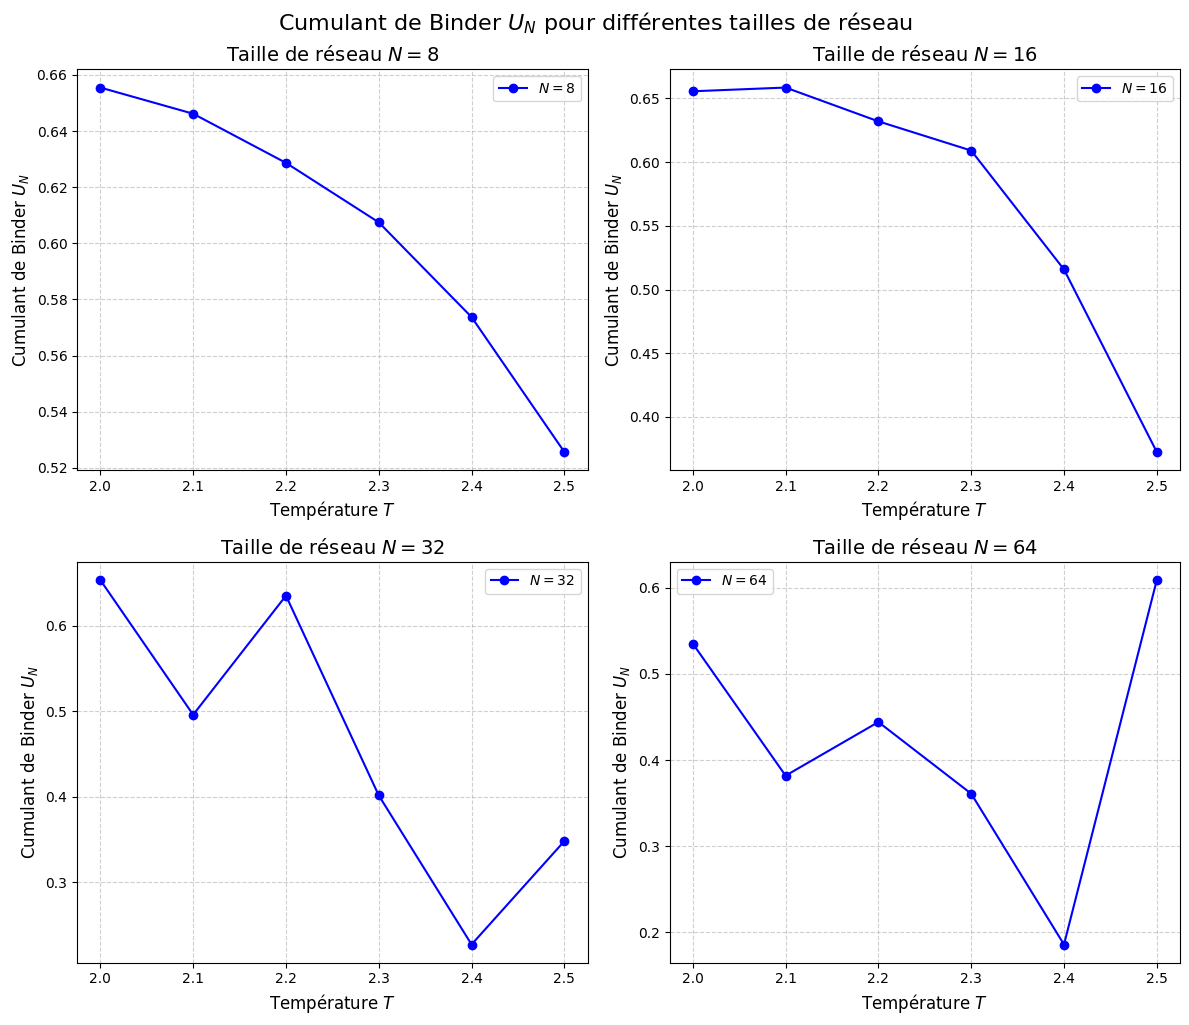

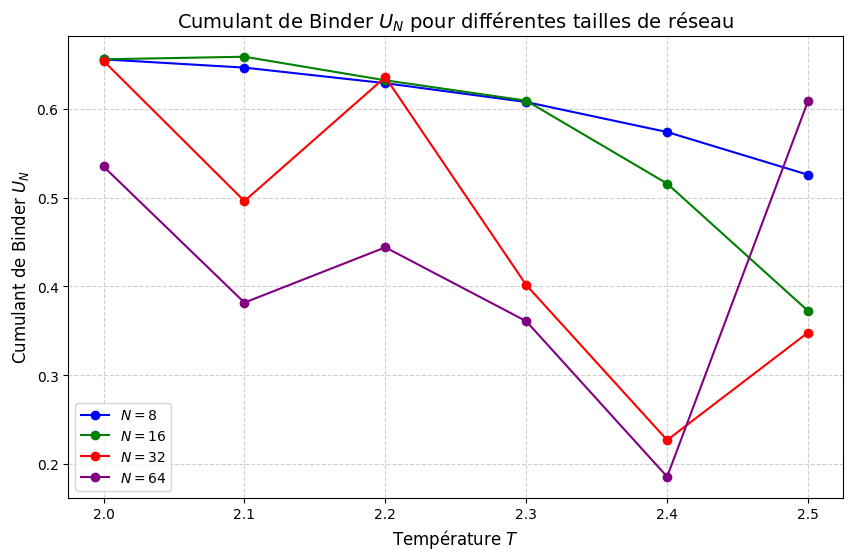

In [ ]:
# Affichage des données par sous-graphiques
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grilles pour 4 tailles
axes = axes.ravel()  # Aplatir les axes pour itérer facilement

for idx, n in enumerate(N):  # Pour chaque taille de réseau
    ax = axes[idx]  # Récupération de l'axe correspondant
    binder_cumulants = []  # Liste pour stocker les U_N pour chaque T
    for T in temperatures:  # Pour chaque température
        # Calcul du cumulant de Binder pour les aimantations m[n][T]
        U_N = cum_Binder(m[n][T], verbosity=2)
        binder_cumulants.append(U_N)

    # Tracé de la courbe pour la taille actuelle
    ax.plot(temperatures, binder_cumulants, color='blue', marker='o', label=f"$N={n}$")

    # Personnalisation du sous-graphe
    ax.set_xlabel(r"Température $T$", fontsize=12)
    ax.set_ylabel(r"Cumulant de Binder $U_N$", fontsize=12)
    ax.set_title(f"Taille de réseau $N = {n}$", fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=10)

# Ajustement de l'espace entre les sous-graphiques
plt.tight_layout()
plt.suptitle("Cumulant de Binder $U_N$ pour différentes tailles de réseau", fontsize=16, y=1.02)  # Titre global
plt.show()


# Affichage des courbes sur un même graphique
colors = ['blue', 'green', 'red', 'purple']  # Palette de couleurs

plt.figure(figsize=(10, 6))  # Taille de la figure

# Pour chaque taille N, tracer le cumulant de Binder
for idx, n in enumerate(N):
    color = colors[idx]  # Couleur différente pour chaque N
    binder_cumulants = []  # Liste pour stocker les valeurs de cumulant pour chaque T
    for T in temperatures:
        U_N = cum_Binder(m[n][T], verbosity=0)  # Calcul du cumulant pour T
        binder_cumulants.append(U_N)

    # Tracé de la courbe pour la taille actuelle
    plt.plot(temperatures, binder_cumulants, color=color, marker='o', label=f"$N={n}$")

# Personnalisation du graphique
plt.xlabel(r"Température $T$", fontsize=12)
plt.ylabel(r"Cumulant de Binder $U_N$", fontsize=12)
plt.title("Cumulant de Binder $U_N$ pour différentes tailles de réseau", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Affichage du graphique
plt.show()

## Q5

### a 
À travers ces graphiques, nous avons cherché à estimer la valeur de la température critique $T_c$ . Un premier constat est que, pour le nombre d’itérations étudiées, seules les trois premières tailles de réseau offrent une précision suffisante pour être exploitées. En effet, pour analyser correctement le cas N = 64 , il serait nécessaire de calculer la moyenne sur un plus grand nombre de valeurs. Cela se reflète également dans les écarts des moyennes observées : les métriques n’ont pas encore atteint un état stable.



Pour les tailles de réseau étudiables, on peut approximativement déterminer que les courbes se croisent entre $T/J = 2.2$ et $T/J = 2.3$ , fournissant ainsi une estimation de la température critique.



Nous avons tenté d’effectuer un zoom pour affiner cette estimation, mais nos simulations actuelles ne permettent pas de déterminer une température critique avec davantage de précision. Pour cela, il serait nécessaire d’augmenter le nombre de simulations et de calculer des moyennes sur un plus grand ensemble de données.








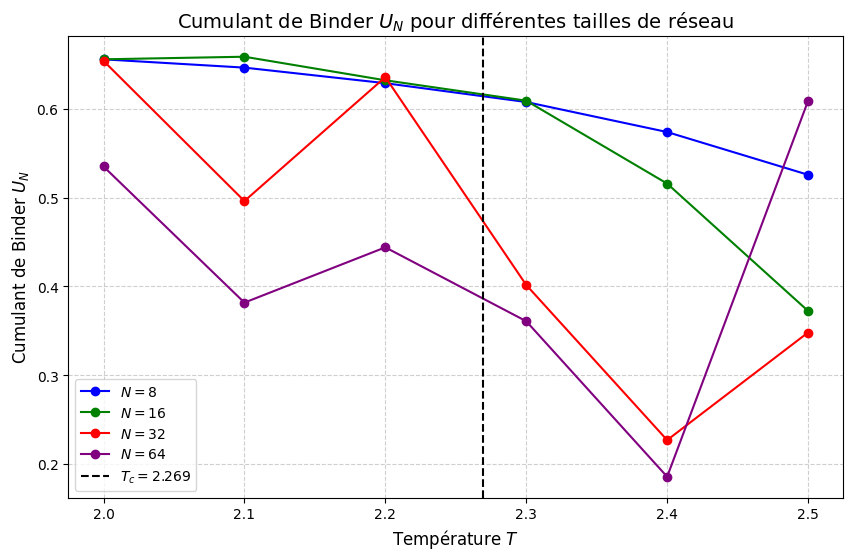

In [ ]:
# Affichage des courbes sur un même graphique
colors = ['blue', 'green', 'red', 'purple']  # Palette de couleurs

plt.figure(figsize=(10, 6))  # Taille de la figure

# Pour chaque taille N, tracer le cumulant de Binder
for idx, n in enumerate(N):
    color = colors[idx]  # Couleur différente pour chaque N
    binder_cumulants = []  # Liste pour stocker les valeurs de cumulant pour chaque T
    for T in temperatures:
        U_N = cum_Binder(m[n][T], verbosity=0)  # Calcul du cumulant pour T
        binder_cumulants.append(U_N)

    # Tracé de la courbe pour la taille actuelle
    plt.plot(temperatures, binder_cumulants, color=color, marker='o', label=f"$N={n}$")

# Ajouter une ligne verticale à T = 2.269
critical_temperature = 2.269  # Température critique
plt.axvline(x=critical_temperature, color='black', linestyle='--', label=r"$T_c = 2.269$")

# Personnalisation du graphique
plt.xlabel(r"Température $T$", fontsize=12)
plt.ylabel(r"Cumulant de Binder $U_N$", fontsize=12)
plt.title("Cumulant de Binder $U_N$ pour différentes tailles de réseau", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Affichage du graphique
plt.show()

In [ ]:
# Paramètres de la simulation 
N = [8, 16, 32, 64]  # Tailles de réseau
temperatures = np.linspace(2.2, 2.3, 10)  # Températures réduites T/J
beta_values = [1 / (T / J) for T in temperatures] # inverse de la temperature
J = 1.0  # Constante d'échange
n_runs = int(1e5) # nombre d'iteration pour faire la moyenne
n_steps = int(1e4) # nombre d'iteration pour atteindre la thermalisation
n_delta = int(1e2) # ecart entre chaque évalutation des metriques
m = {n: {T: [] for T in temperatures} for n in N} # Initialisation des listes pour stocker les résultats]
temp = 0

for n  in N :
    s_init = np.random.choice([-1, 1], size=(n, n)) # tableau de spins initiaux  de taille NxN
    for beta in beta_values :
        s = metropolis_simulation_2d(s_init, J, beta, n_steps, verbosity = 0) 
        for it in range(n_runs):
            s = metropolis_simulation_2d(s, J, beta, n_delta, verbosity = 0)
            m_temp = aimantation(s, verbosity = 0)
            m[n][1/beta].append(m_temp)

            if verbosity > 2:
                print(f"N = {n}, T = {1/beta}, aimantation = {m_temp:.4f}")

    if verbosity > 1 : 
        if verbosity > 2 : 
            print("\n")
        print(f"Progression : {100 * (temp + 1) / len(N):.2f}%")
        temp += 1

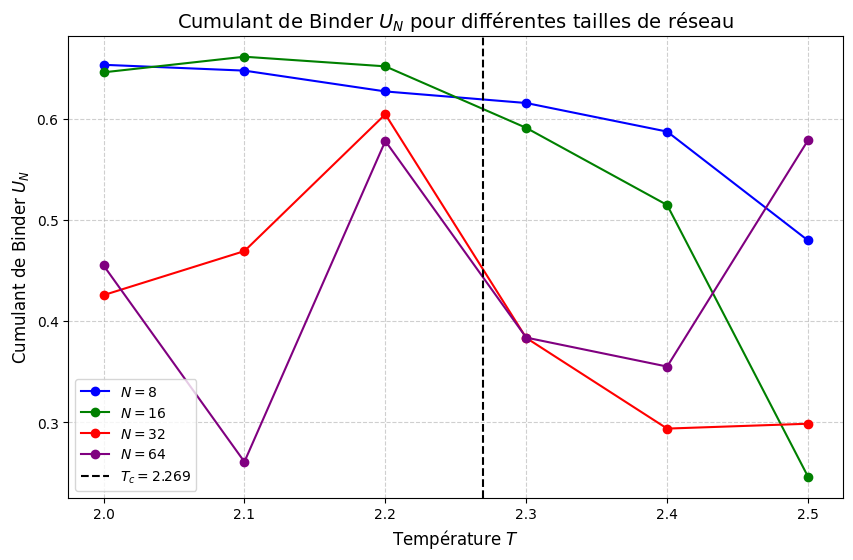

In [ ]:
# Affichage des courbes sur un même graphique
colors = ['blue', 'green', 'red', 'purple']  # Palette de couleurs

plt.figure(figsize=(10, 6))  # Taille de la figure

# Pour chaque taille N, tracer le cumulant de Binder
for idx, n in enumerate(N):
    color = colors[idx]  # Couleur différente pour chaque N
    binder_cumulants = []  # Liste pour stocker les valeurs de cumulant pour chaque T
    for T in temperatures:
        U_N = cum_Binder(m[n][T], verbosity=0)  # Calcul du cumulant pour T
        binder_cumulants.append(U_N)

    # Tracé de la courbe pour la taille actuelle
    plt.plot(temperatures, binder_cumulants, color=color, marker='o', label=f"$N={n}$")

# Ajouter une ligne verticale à T = 2.269
critical_temperature = 2.269  # Température critique
plt.axvline(x=critical_temperature, color='black', linestyle='--', label=r"$T_c = 2.269$")

# Personnalisation du graphique
plt.xlabel(r"Température $T$", fontsize=12)
plt.ylabel(r"Cumulant de Binder $U_N$", fontsize=12)
plt.title("Cumulant de Binder $U_N$ pour différentes tailles de réseau", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Affichage du graphique
plt.show()

### b 



Nous comparons ensuite notre estimation avec la valeur exacte $T_c/J \approx 2.269$ , déterminée par Onsager. Nos simulations ont permis d’obtenir une approximation de la température critique à l’ordre du dixième, mais elles ne sont pas suffisamment précises pour aller au-delà. Afin d’améliorer nos résultats, il serait pertinent d’accroître le nombre de points de mesure et de moyens sur lesquels effectuer les moyennes.

## Sources

Physique statistique 2 : Transitions de phase, École Polytechnique Fédérale de Lausanne, Prof. Matthieu Wyart, Rédigé par Jonas Paccolat
